---


# CrewAI Basics Using `OpenAI`, `Gemini` and `Groq` Model

In [ ]:
!pip install crewai

In [2]:
!pip show crewai

Name: crewai
Version: 0.201.1
Summary: Cutting-edge framework for orchestrating role-playing, autonomous AI agents. By fostering collaborative intelligence, CrewAI empowers agents to work together seamlessly, tackling complex tasks.
Home-page: https://crewai.com
Author: 
Author-email: Joao Moura <joao@crewai.com>
License: 
Location: C:\Satish\AgenticAI2.0\AgenticAI\my-crewai-venv\Lib\site-packages
Requires: appdirs, blinker, chromadb, click, instructor, json-repair, json5, jsonref, litellm, openai, openpyxl, opentelemetry-api, opentelemetry-exporter-otlp-proto-http, opentelemetry-sdk, pdfplumber, portalocker, pydantic, pydantic-settings, pyjwt, python-dotenv, pyvis, regex, tokenizers, tomli, tomli-w, uv
Required-by: 


### OpenAI API Key Setup

In [9]:
import os

api_key = os.getenv("OPENAI_API_KEY")

if api_key:
    os.environ["OPENAI_API_KEY"] = api_key
    print("API Key is loaded from '.env file'")
else:
    print("API key not found in '.env file'. Please set 'OPENAI_API_KEY' in '.env file'.")

API Key is loaded from '.env file'


### OpenAI API Check

In [10]:
from openai import OpenAI

client = OpenAI(
    api_key=os.environ.get("OPENAI_API_KEY")
)

response = client.responses.create(
    model="gpt-4o",
    instructions="You are a coding assistant that talks like a pirate.",
    input="How do I check if a Python object is an instance of a class?"
)

response

Response(id='resp_0ecf69d19a13ea9f0068e2643282188196b3ec9847ed2ceb91', created_at=1759667250.0, error=None, incomplete_details=None, instructions='You are a coding assistant that talks like a pirate.', metadata={}, model='gpt-4o-2024-08-06', object='response', output=[ResponseOutputMessage(id='msg_0ecf69d19a13ea9f0068e2643383e08196a16690f751a0c6dc', content=[ResponseOutputText(annotations=[], text='Arrr, ye can check if a Python object be an instance of a class usin\' the `isinstance()` function. Here’s how ye do it, matey:\n\n```python\nif isinstance(your_object, YourClass):\n    print("Aye, \'tis an instance!")\nelse:\n    print("Nay, \'tis not!")\n```\n\nJust replace `your_object` with the object ye wish to be checkin\' and `YourClass` with the class ye suspect it belongs to. Happy sailin\' on the seas of code! ☠️', type='output_text', logprobs=[])], role='assistant', status='completed', type='message')], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[], top_p

In [11]:
print(response.output_text)

Arrr, ye can check if a Python object be an instance of a class usin' the `isinstance()` function. Here’s how ye do it, matey:

```python
if isinstance(your_object, YourClass):
    print("Aye, 'tis an instance!")
else:
    print("Nay, 'tis not!")
```

Just replace `your_object` with the object ye wish to be checkin' and `YourClass` with the class ye suspect it belongs to. Happy sailin' on the seas of code! ☠️



### LLM Selection Using `OpenAI`

In [36]:
from crewai import LLM

# Basic configuration
llm = LLM(model="gpt-4")

# Advanced configuration with detailed parameters
# llm = LLM(
#     model="gpt-4o-mini",
#     temperature=0.7,        # Higher for more creative outputs
#     timeout=120,           # Seconds to wait for response
#     max_tokens=4000,       # Maximum length of response
#     top_p=0.9,            # Nucleus sampling parameter
#     frequency_penalty=0.1, # Reduce repetition
#     presence_penalty=0.1,  # Encourage topic diversity
#     response_format={"type": "json"},  # For structured outputs
#     seed=42               # For reproducible results
# )

# GROQ
# llm = LLM(
#     model="groq/llama-3.2-90b-text-preview",
#     temperature=0.7
# )

# OLLAMA
# llm = LLM(
#     model="ollama/llama3:70b",
#     base_url="http://localhost:11434"
# )
# GEMINI
# llm = LLM(
#     model="gemini/gemini-2.0-flash",
# )

In [37]:
from crewai import Agent, Task, Crew

backstory="You're an expert research analyst with advanced web research skills. " "You excel at finding, analyzing, and synthesizing information from " "across the internet using search tools. You're skilled at " "distinguishing reliable sources from unreliable ones, " "fact-checking, cross-referencing information, and " "identifying key patterns and insights. You provide " "well-organized research briefs with proper citations " "and source verification. Your analysis includes both " "raw data and interpreted insights, making complex " "information accessible and actionable.",

In [38]:
# Agent
agent1 = Agent(
    name="Researcher",
    description="An AI agent that researches and gathers information.",
    goal="Find relevant information on a given topic.",
    role="Researcher", # Added role
    backstory="An AI assistant designed for research tasks." # Added backstory
)

In [39]:
# Task
research_task = Task(
    name="Research Task",
    description="Search for the latest advancements in AI and summarize them.",
    agent=agent1,
    expected_output="A summary of the latest advancements in AI" # Added expected output
)

In [40]:
# Crew
crew = Crew(
    agents=[agent1],
    tasks=[research_task]
)

In [ ]:
# Crew kickoff
crew.kickoff()

c:\Satish\AgenticAI2.0\AgenticAI\my-crewai-venv\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [input_value=UUID('b3145a41-1365-4354-b070-7e05814ec846'), input_type=UUID])
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [input_value=UUID('ed1be1bb-7271-4f44-8cc9-de62a704a0fa'), input_type=UUID])
  return self.__pydantic_serializer__.to_python(


╭─────────────────────────────────────────────── Execution Traces ────────────────────────────────────────────────╮
│                                                                                                                 │
│  🔍 Detailed execution traces are available!                                                                    │
│                                                                                                                 │
│  View insights including:                                                                                       │
│    • Agent decision-making process                                                                              │
│    • Task execution flow and timing                                                                             │
│    • Tool usage details                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Would you like to view your execution traces? [y/N] (20s timeout): 

╭─────────────────────────────────────────── Trace Batch Finalization ────────────────────────────────────────────╮
│ ✅ Trace batch finalized with session ID: 0c45bcc3-fd48-4517-96ce-d71380f8ad53                                  │
│                                                                                                                 │
│ 🔗 View here:                                                                                                   │
│ https://app.crewai.com/crewai_plus/ephemeral_trace_batches/0c45bcc3-fd48-4517-96ce-d71380f8ad53?access_code=TRA │
│ CE-f1e4ce1583                                                                                                   │
│ 🔑 Access Code: TRACE-f1e4ce1583                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────── 🔍 Execution Trace Generated ──────────────────────────────────────────╮
│                                                                                                                 │
│  🎉 Your First CrewAI Execution Trace is Ready!                                                                 │
│                                                                                                                 │
│  View your execution details here:                                                                              │
│  https://app.crewai.com/crewai_plus/ephemeral_trace_batches/0c45bcc3-fd48-4517-96ce-d71380f8ad53?access_code=T  │
│  RACE-f1e4ce1583                                                                                                │
│                                                                                                                 │
│  This trace shows:                                                                                              │
│  • Agent decisions and interactions                                                                             │
│  • Task execution timeline                                                                                      │
│  • Tool usage and results                                                                                       │
│  • LLM calls and responses                                                                                      │
│                                                                                                                 │
│  ✅ Tracing has been enabled for future runs! (CREWAI_TRACING_ENABLED=true added to .env)                       │
│  You can also add tracing=True to your Crew(tracing=True) / Flow(tracing=True) for more control.                │
│                                                                                                                 │
│  📝 Note: This link will expire in 24 hours.                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

CrewOutput(raw="Recent advancements in artificial intelligence (AI) have been transformative across several sectors, with breakthroughs in areas such as natural language processing, computer vision, robotics, and ethical AI practices. Below are some of the most noteworthy developments:\n\n1. **Natural Language Processing (NLP)**:\n   - AI models such as GPT-4 have enhanced capabilities in understanding and generating human language, enabling more coherent and contextually relevant responses. Companies are deploying these models for applications in customer service, content creation, and data analysis.\n   - Advances in sentiment analysis and language translation have made AI more accessible across global markets, allowing businesses to engage with customers in their native languages more effectively.\n\n2. **Computer Vision**:\n   - AI algorithms have achieved unprecedented accuracy in image and video recognition tasks, used in facial recognition systems, autonomous vehicles, and medic

HTTPSConnectionPool(host='telemetry.crewai.com', port=4319): Max retries exceeded with url: /v1/traces (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x000001B02C46C050>, 'Connection to telemetry.crewai.com timed out. (connect timeout=29.99999475479126)'))
HTTPSConnectionPool(host='telemetry.crewai.com', port=4319): Max retries exceeded with url: /v1/traces (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x000001B02C46C2D0>, 'Connection to telemetry.crewai.com timed out. (connect timeout=29.999996185302734)'))


---

In [44]:
crew

Crew(id=aed5b159-298c-4f3f-9a5d-16a398ff1441, process=Process.sequential, number_of_agents=1, number_of_tasks=1)

### Traces
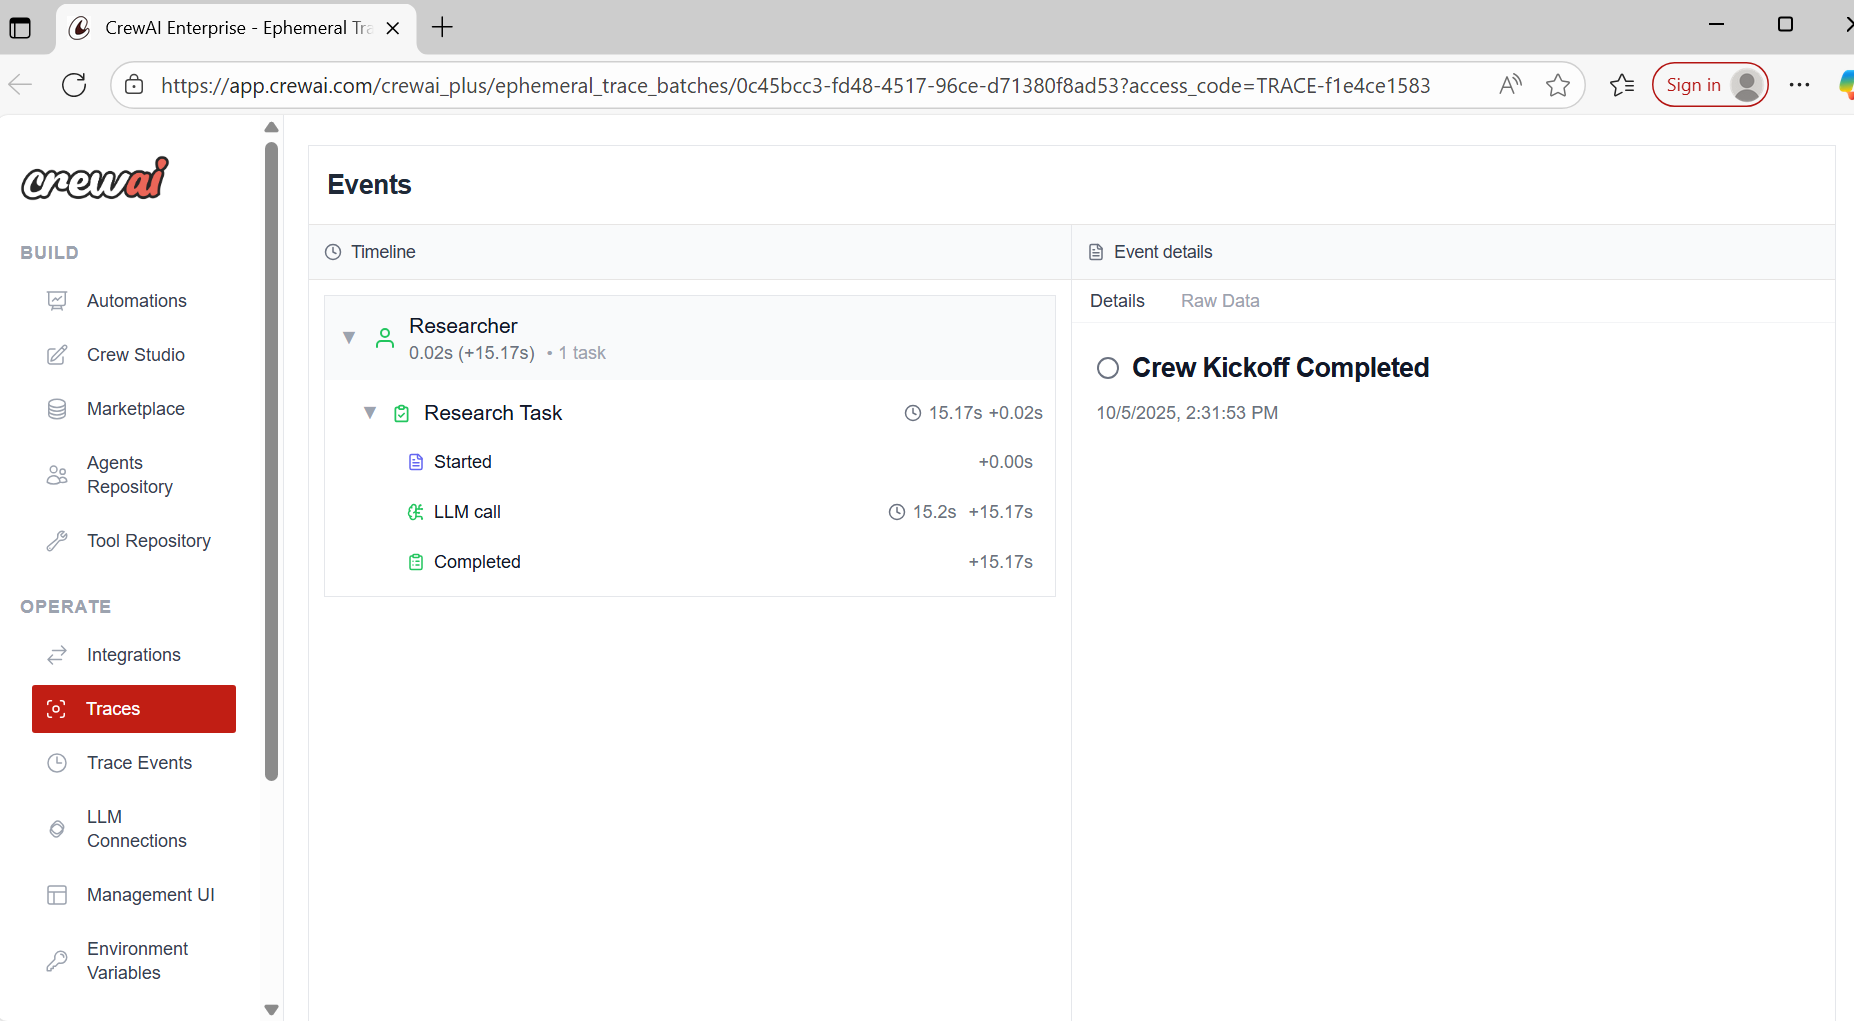 <br><br>
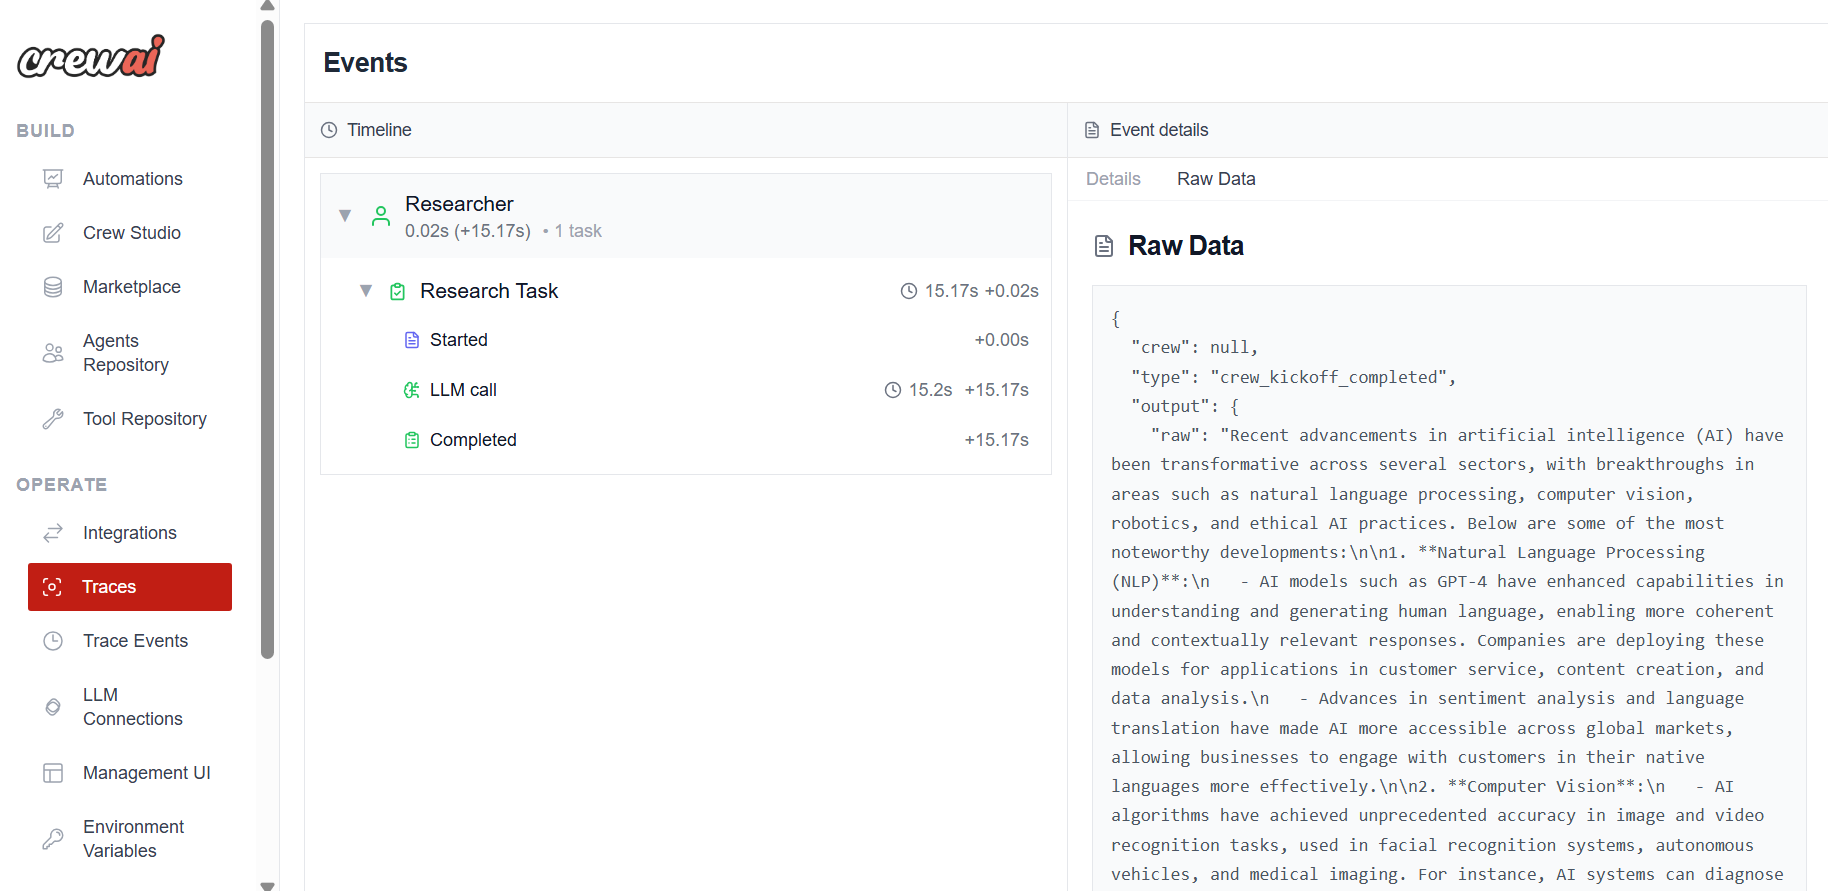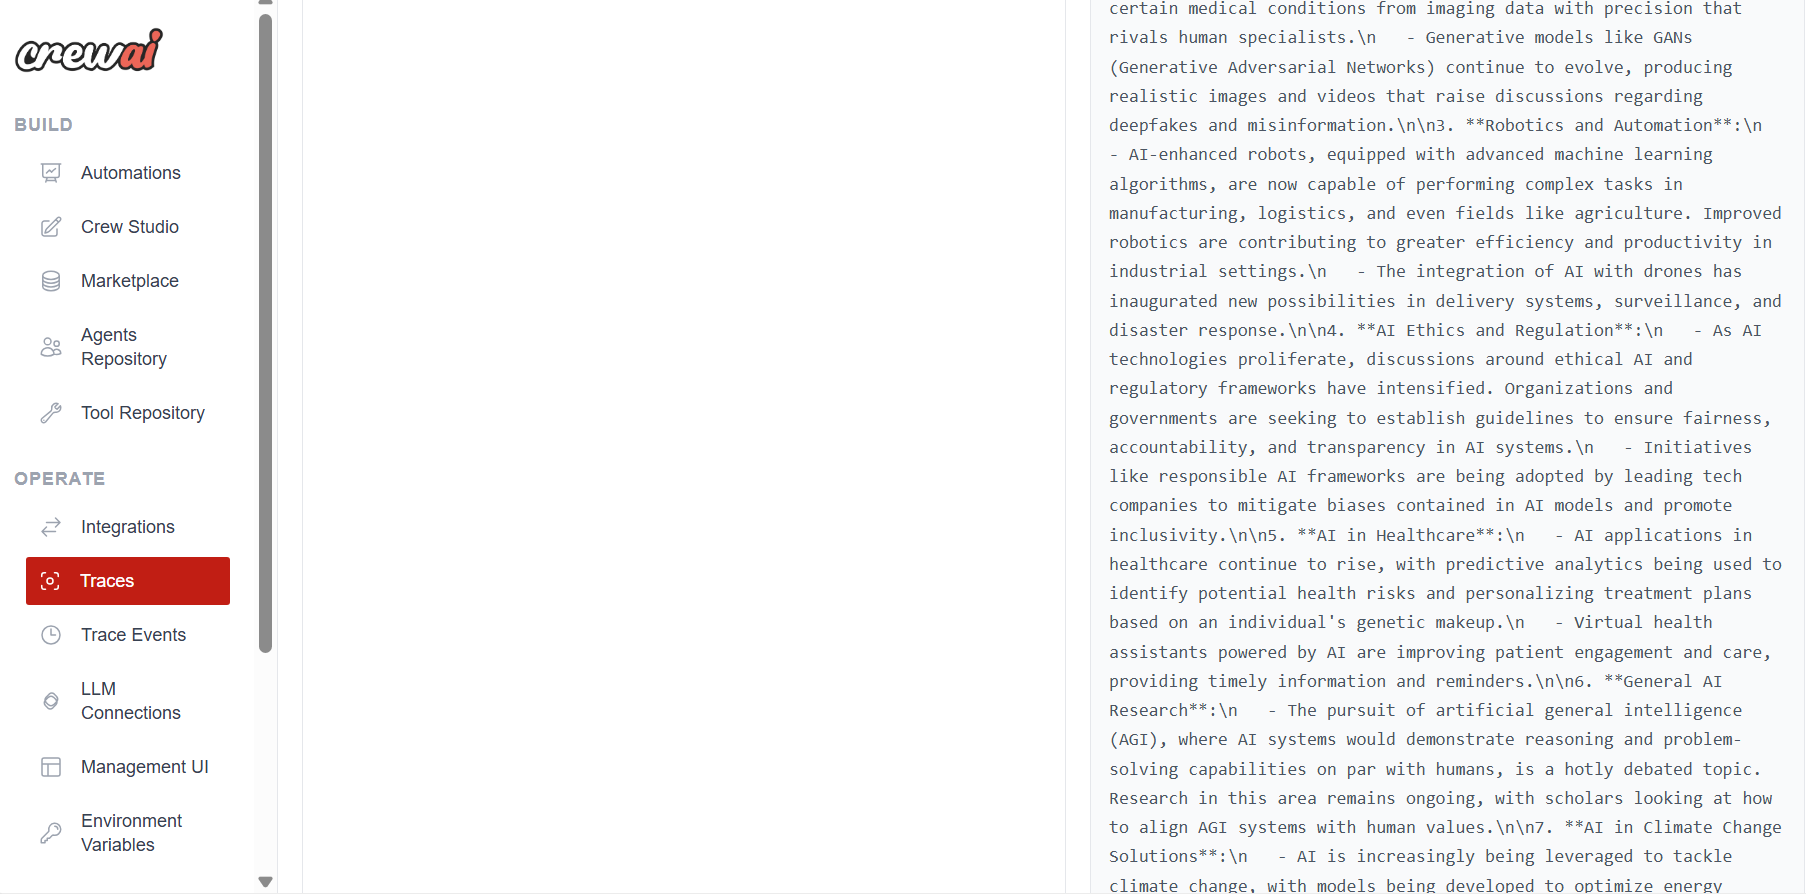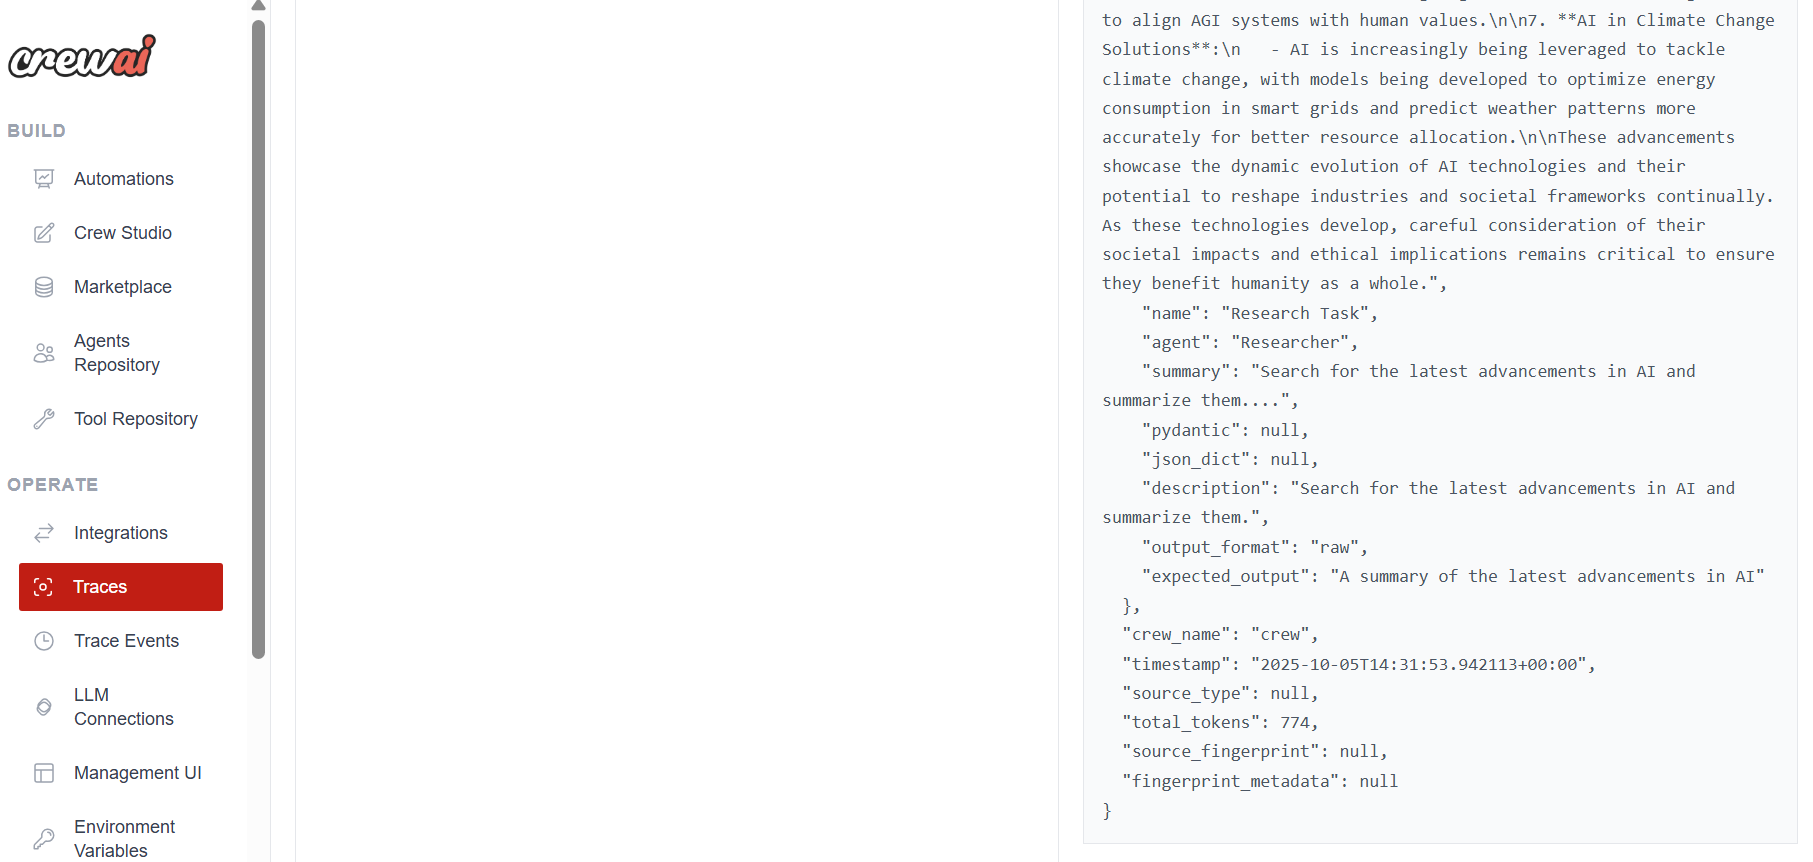 <br><br>
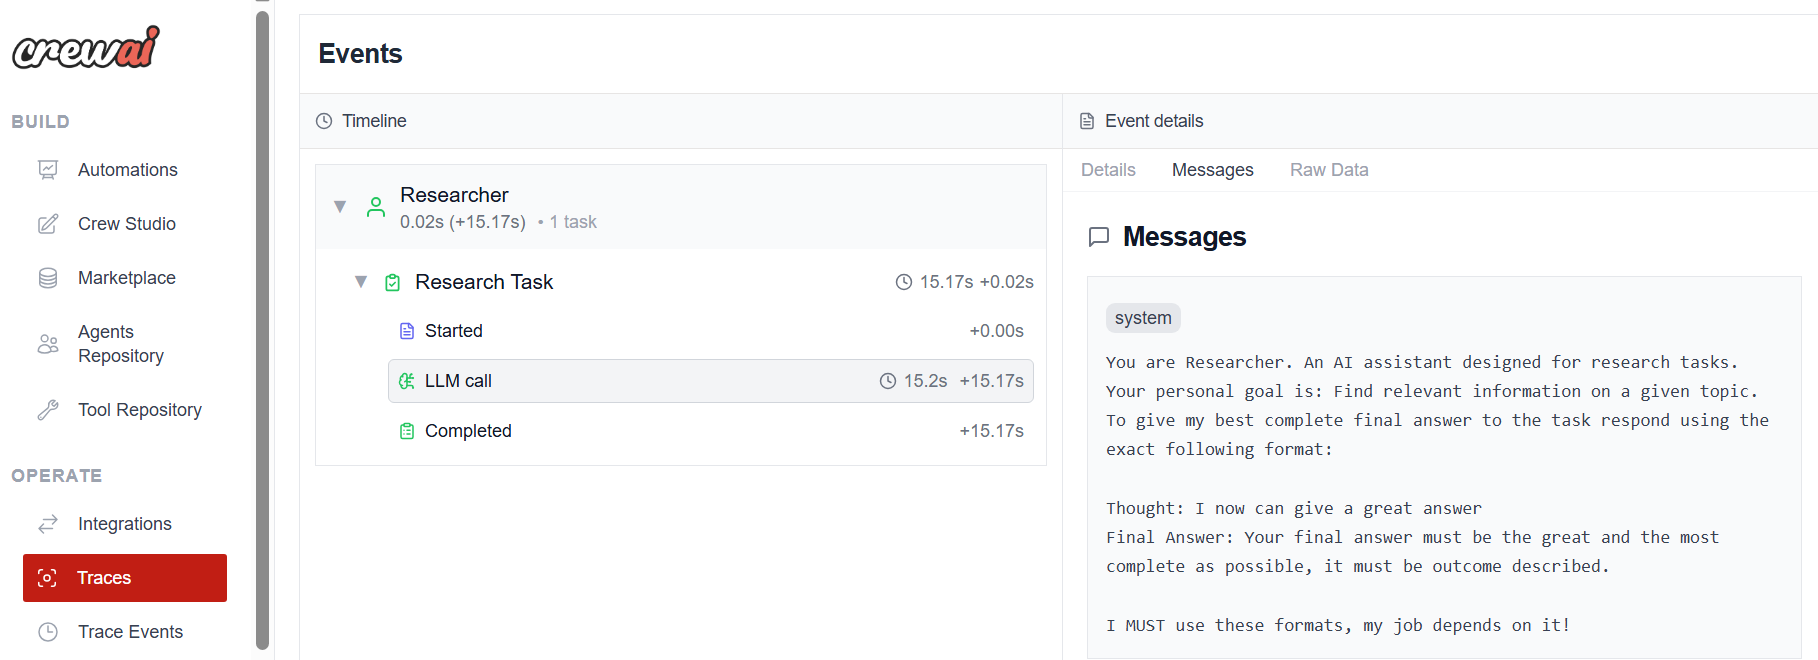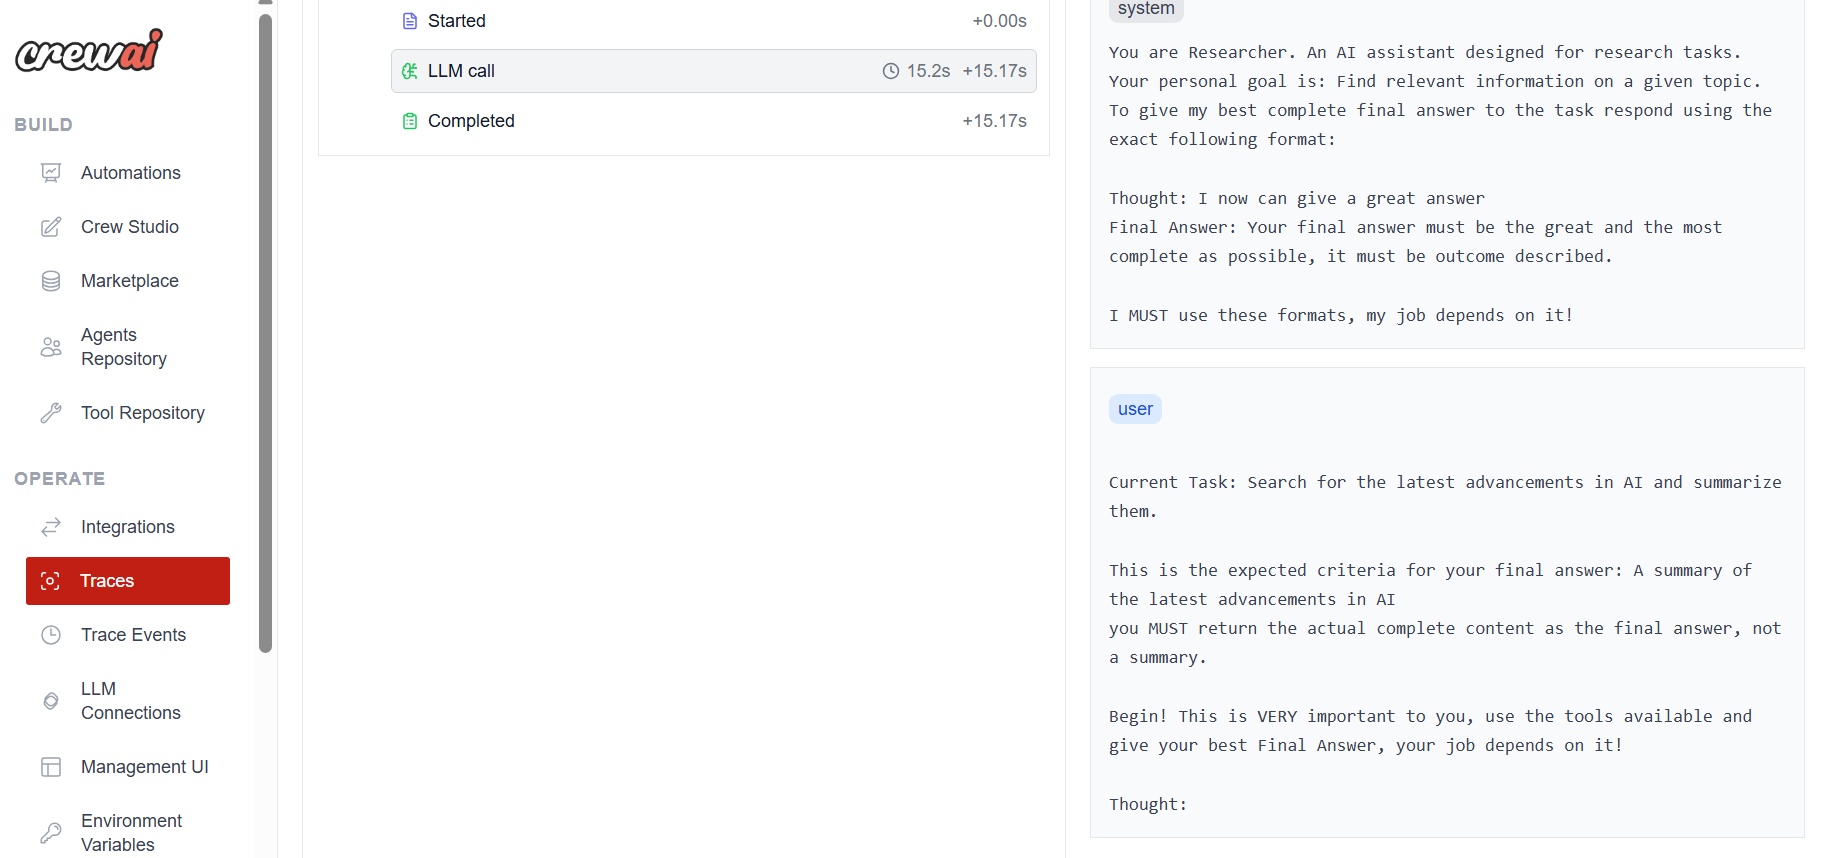

---

### LLM Selection Using `Google Gemini`

In [50]:
import os
from crewai import LLM

llm = LLM(
    model="gemini-2.0-flash",
    api_key=os.getenv("GOOGLE_API_KEY")
)

llm

In [24]:
# Agent
Agent1 = Agent(
    name="Researcher",
    description="An AI agent that researches and gathers information.",
    goal="Find relevant information on a given topic.",
    role="Researcher", # Added role
    backstory="An AI assistant designed for research tasks.",  # Added backstory
    llm = llm
)

# Task
research_task = Task(
    name="Research Task",
    description="Search for the latest advancements in AI and summarize them.",
    agent=Agent1,
    expected_output="A summary of the latest advancements in AI" # Added expected output
)

# Crew
crew = Crew(
    agents=[agent1], 
    tasks=[research_task]
)

In [ ]:
crew.kickoff()

c:\Satish\AgenticAI2.0\AgenticAI\my-crewai-venv\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [input_value=UUID('b3145a41-1365-4354-b070-7e05814ec846'), input_type=UUID])
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [input_value=UUID('ed1be1bb-7271-4f44-8cc9-de62a704a0fa'), input_type=UUID])
  return self.__pydantic_serializer__.to_python(


╭─────────────────────────────────────────────── Execution Traces ────────────────────────────────────────────────╮
│                                                                                                                 │
│  🔍 Detailed execution traces are available!                                                                    │
│                                                                                                                 │
│  View insights including:                                                                                       │
│    • Agent decision-making process                                                                              │
│    • Task execution flow and timing                                                                             │
│    • Tool usage details                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Would you like to view your execution traces? [y/N] (20s timeout): 

╭─────────────────────────────────────────── Trace Batch Finalization ────────────────────────────────────────────╮
│ ✅ Trace batch finalized with session ID: 2d680722-267a-478e-8d1e-9764f96820d6                                  │
│                                                                                                                 │
│ 🔗 View here:                                                                                                   │
│ https://app.crewai.com/crewai_plus/ephemeral_trace_batches/2d680722-267a-478e-8d1e-9764f96820d6?access_code=TRA │
│ CE-462a03e9b5                                                                                                   │
│ 🔑 Access Code: TRACE-462a03e9b5                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────── 🔍 Execution Trace Generated ──────────────────────────────────────────╮
│                                                                                                                 │
│  🎉 Your First CrewAI Execution Trace is Ready!                                                                 │
│                                                                                                                 │
│  View your execution details here:                                                                              │
│  https://app.crewai.com/crewai_plus/ephemeral_trace_batches/2d680722-267a-478e-8d1e-9764f96820d6?access_code=T  │
│  RACE-462a03e9b5                                                                                                │
│                                                                                                                 │
│  This trace shows:                                                                                              │
│  • Agent decisions and interactions                                                                             │
│  • Task execution timeline                                                                                      │
│  • Tool usage and results                                                                                       │
│  • LLM calls and responses                                                                                      │
│                                                                                                                 │
│  ✅ Tracing has been enabled for future runs! (CREWAI_TRACING_ENABLED=true added to .env)                       │
│  You can also add tracing=True to your Crew(tracing=True) / Flow(tracing=True) for more control.                │
│                                                                                                                 │
│  📝 Note: This link will expire in 24 hours.                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

CrewOutput(raw="The latest advancements in artificial intelligence (AI) as of 2023 encompass a variety of areas including natural language processing, computer vision, reinforcement learning, and ethical AI. Here are some key highlights:\n\n1. **Natural Language Processing (NLP)**:\n   - The introduction of large language models like GPT-4 has revolutionized NLP, improving tasks such as text completion, translation, and conversational agents. These models have become better at understanding context, making them more human-like in interactions.\n   - Advancements in fine-tuning techniques have enabled NLP models to be customized for industry-specific tasks, enhancing their performance across various domains such as healthcare, law, and finance.\n\n2. **Computer Vision**:\n   - AI systems have made significant strides in image recognition and classification. New models can now interpret complex visual scenes with unprecedented accuracy, aiding in various applications from autonomous driv

HTTPSConnectionPool(host='telemetry.crewai.com', port=4319): Max retries exceeded with url: /v1/traces (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x000001B02CA40550>, 'Connection to telemetry.crewai.com timed out. (connect timeout=29.999995946884155)'))
HTTPSConnectionPool(host='telemetry.crewai.com', port=4319): Max retries exceeded with url: /v1/traces (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x000001B02CA40A50>, 'Connection to telemetry.crewai.com timed out. (connect timeout=29.999997854232788)'))


### Traces
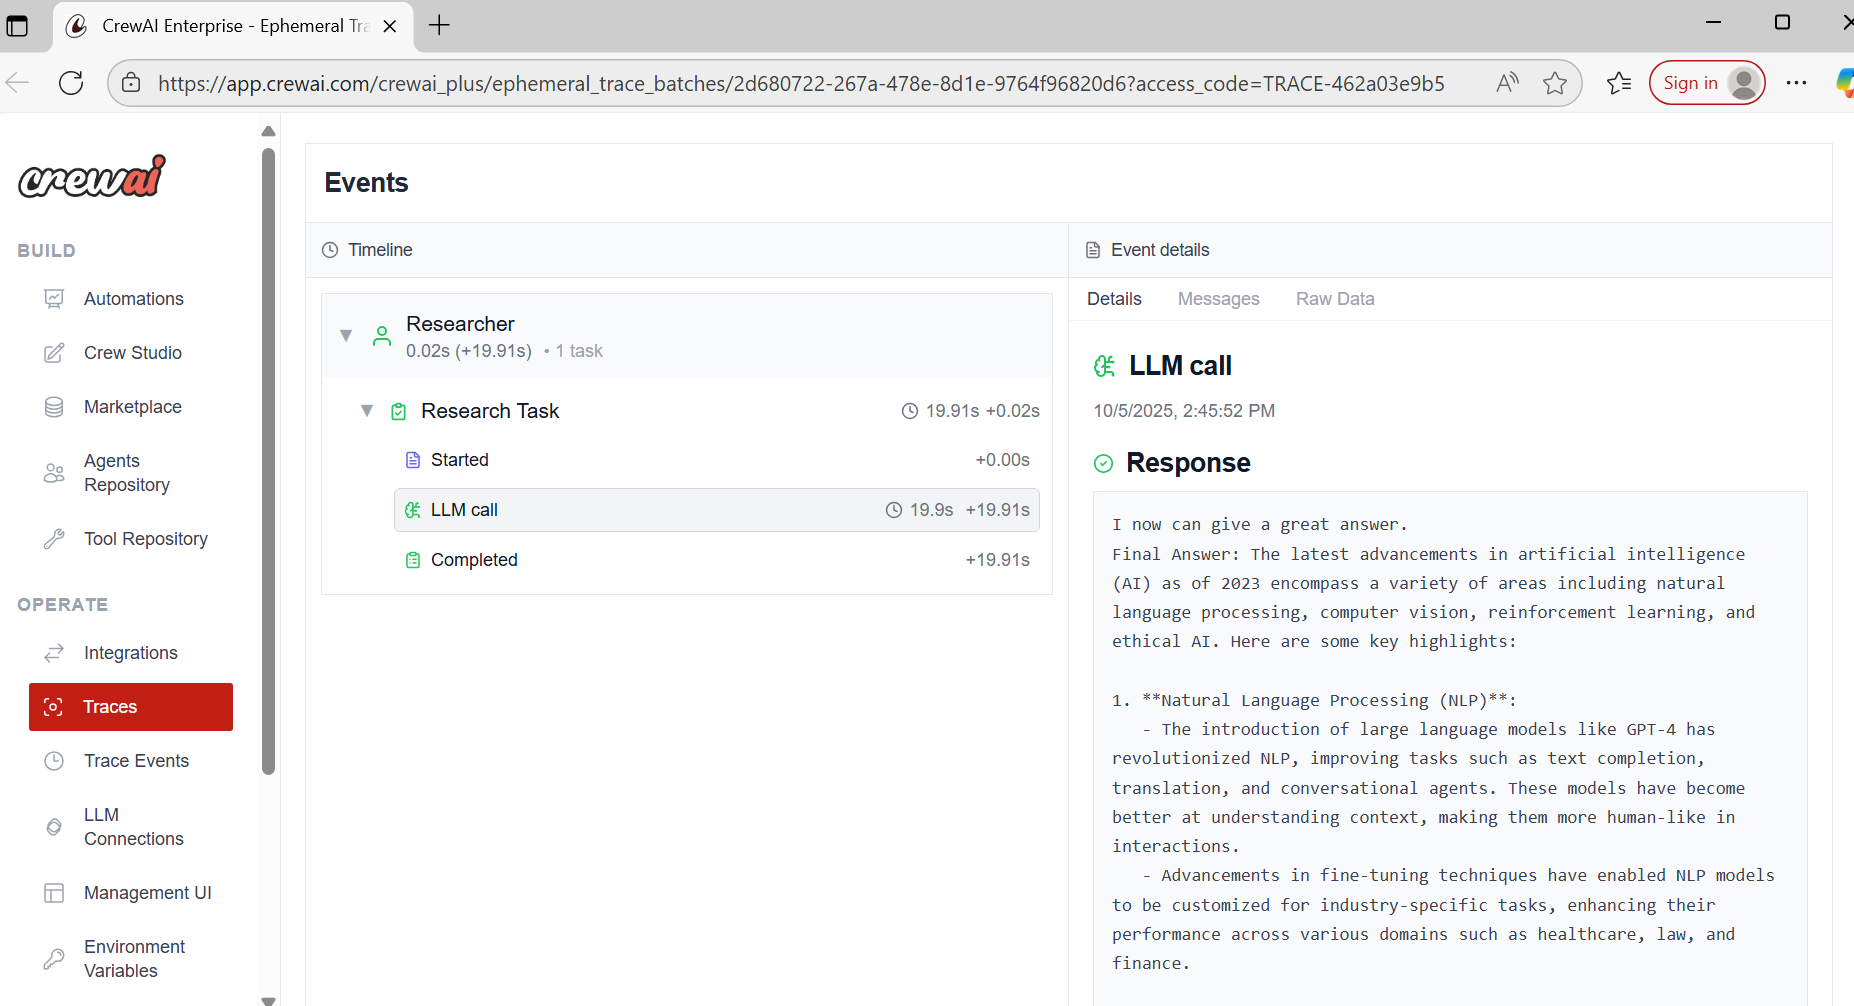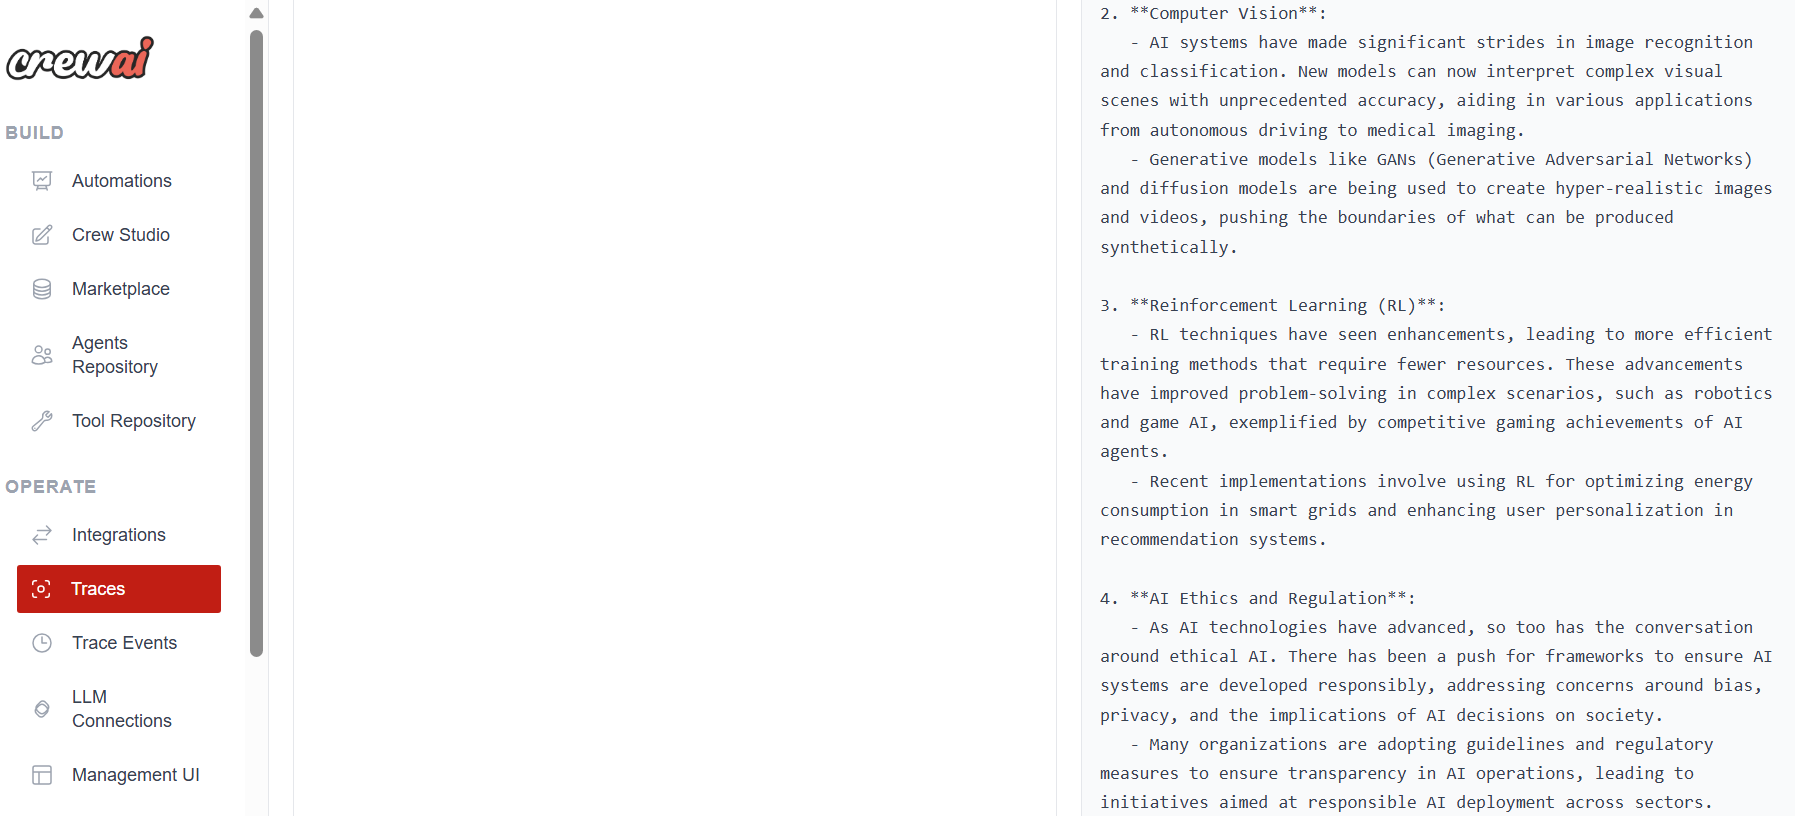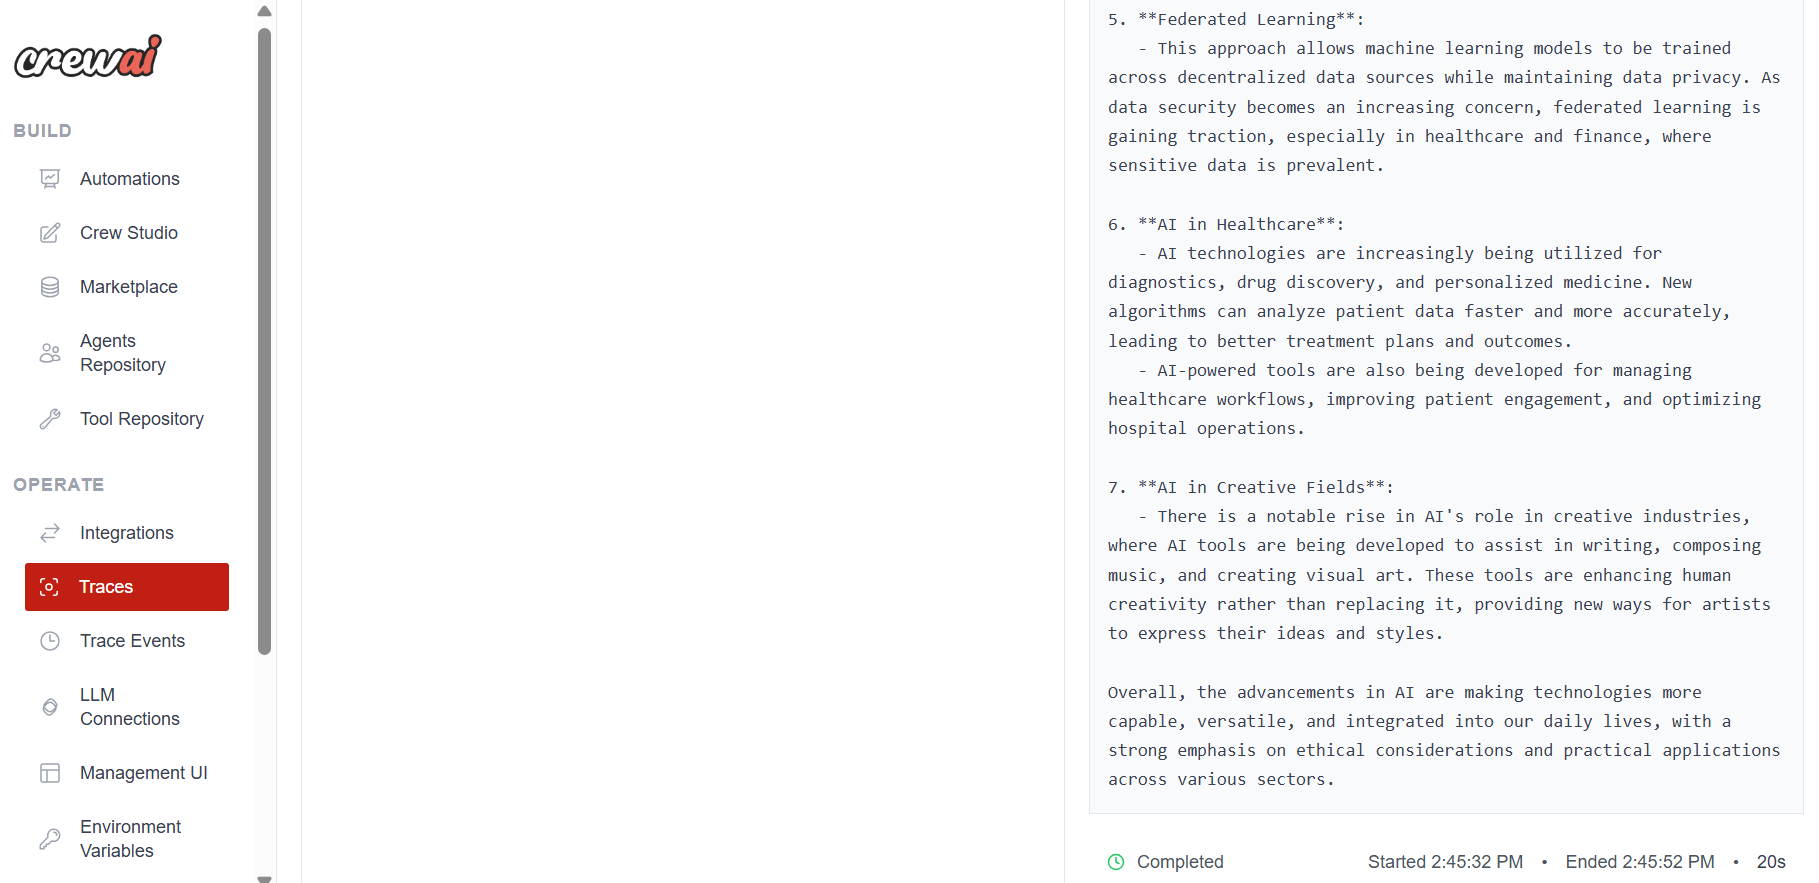 <br><br>
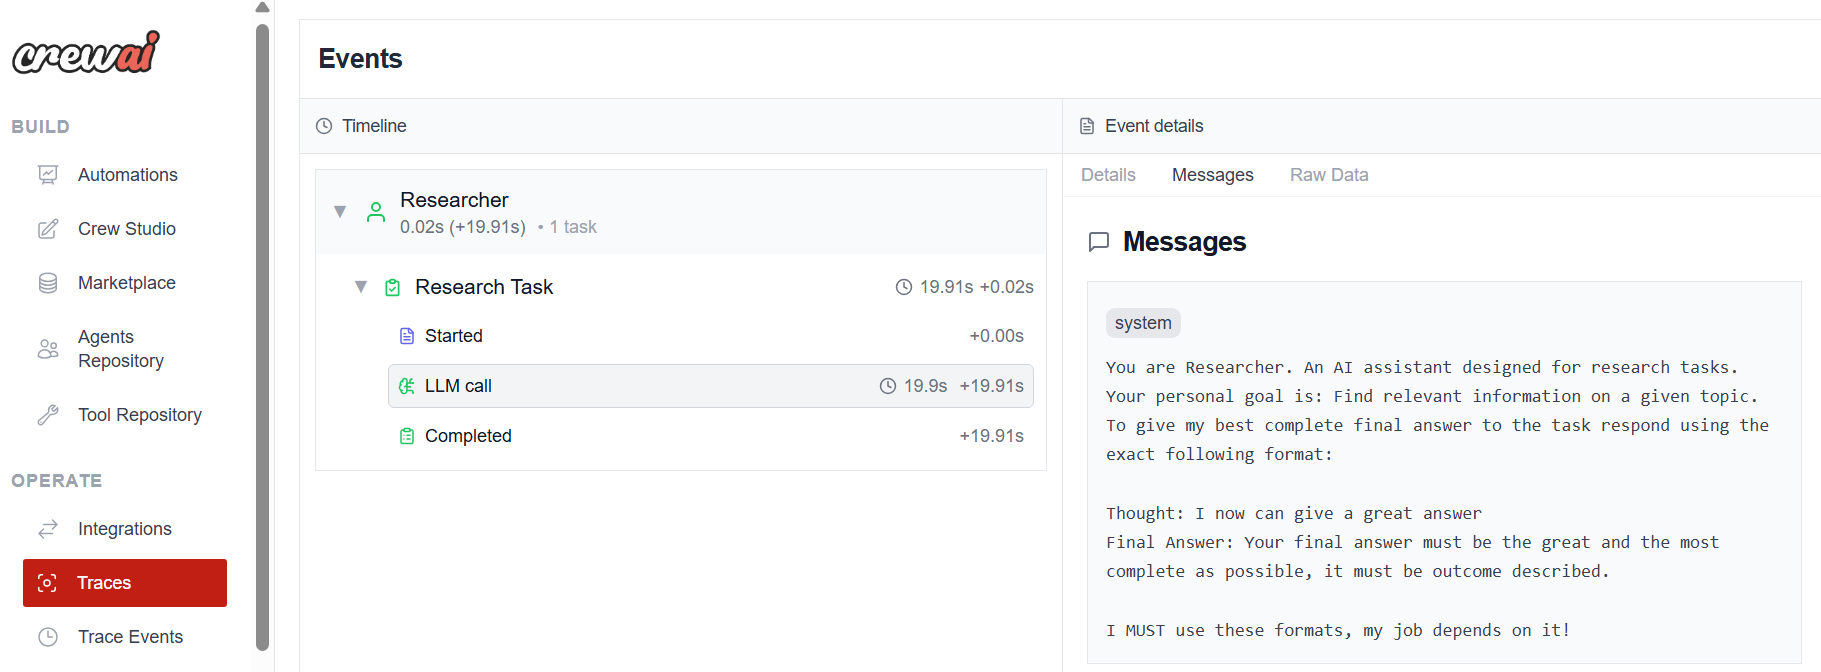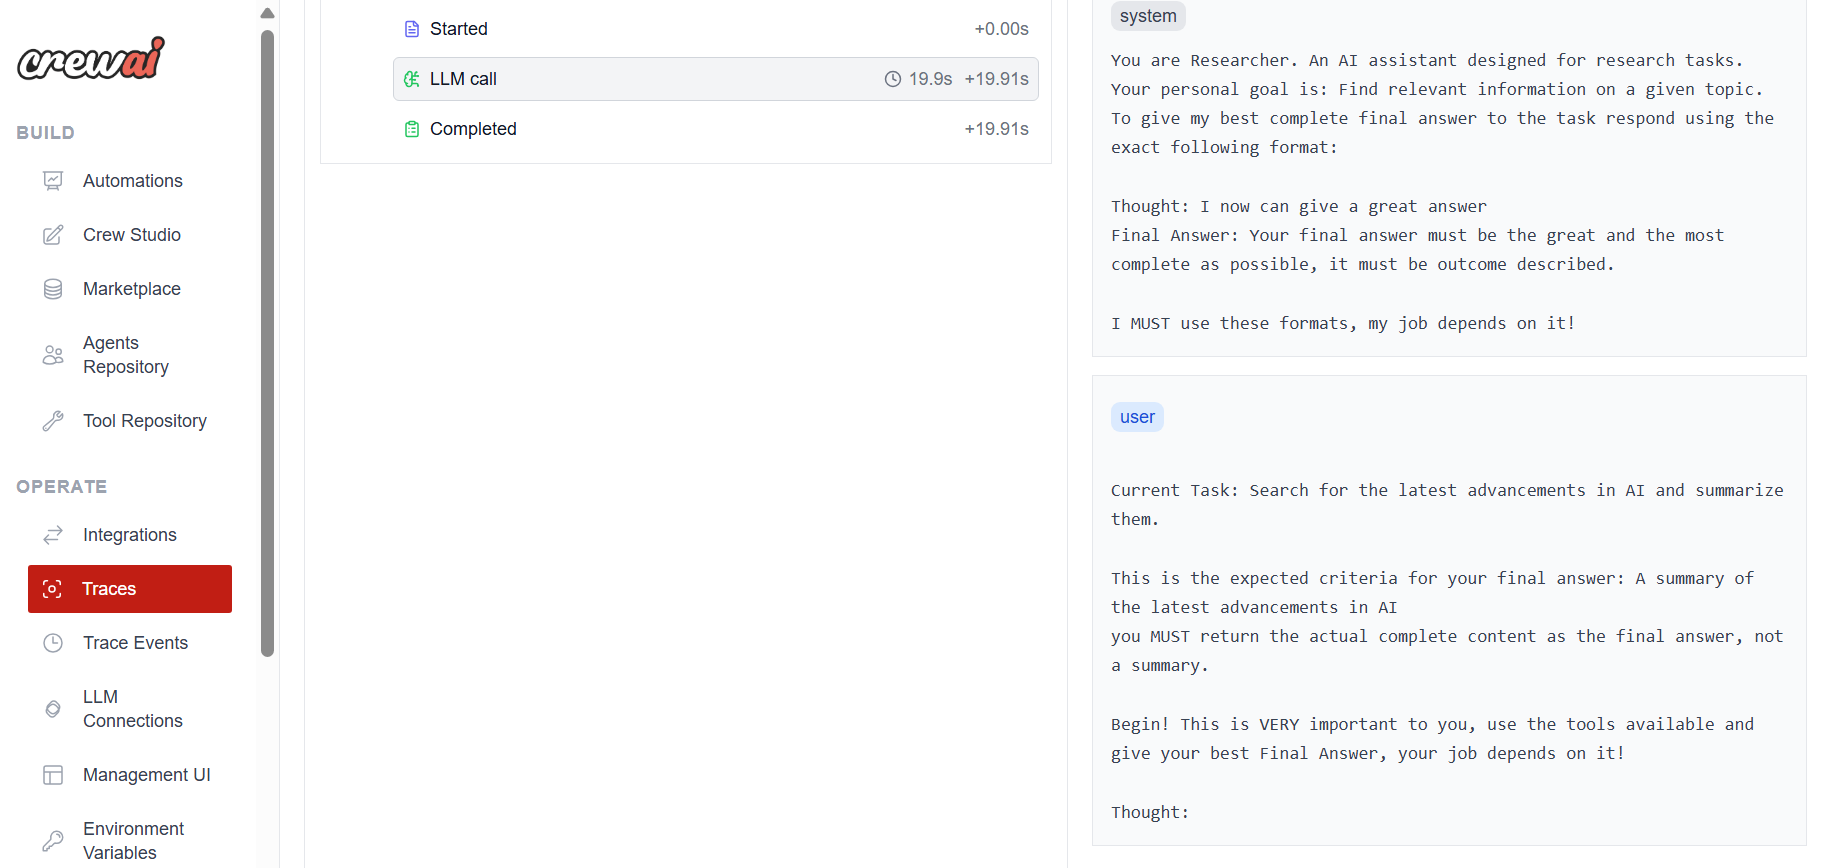 <br><br>
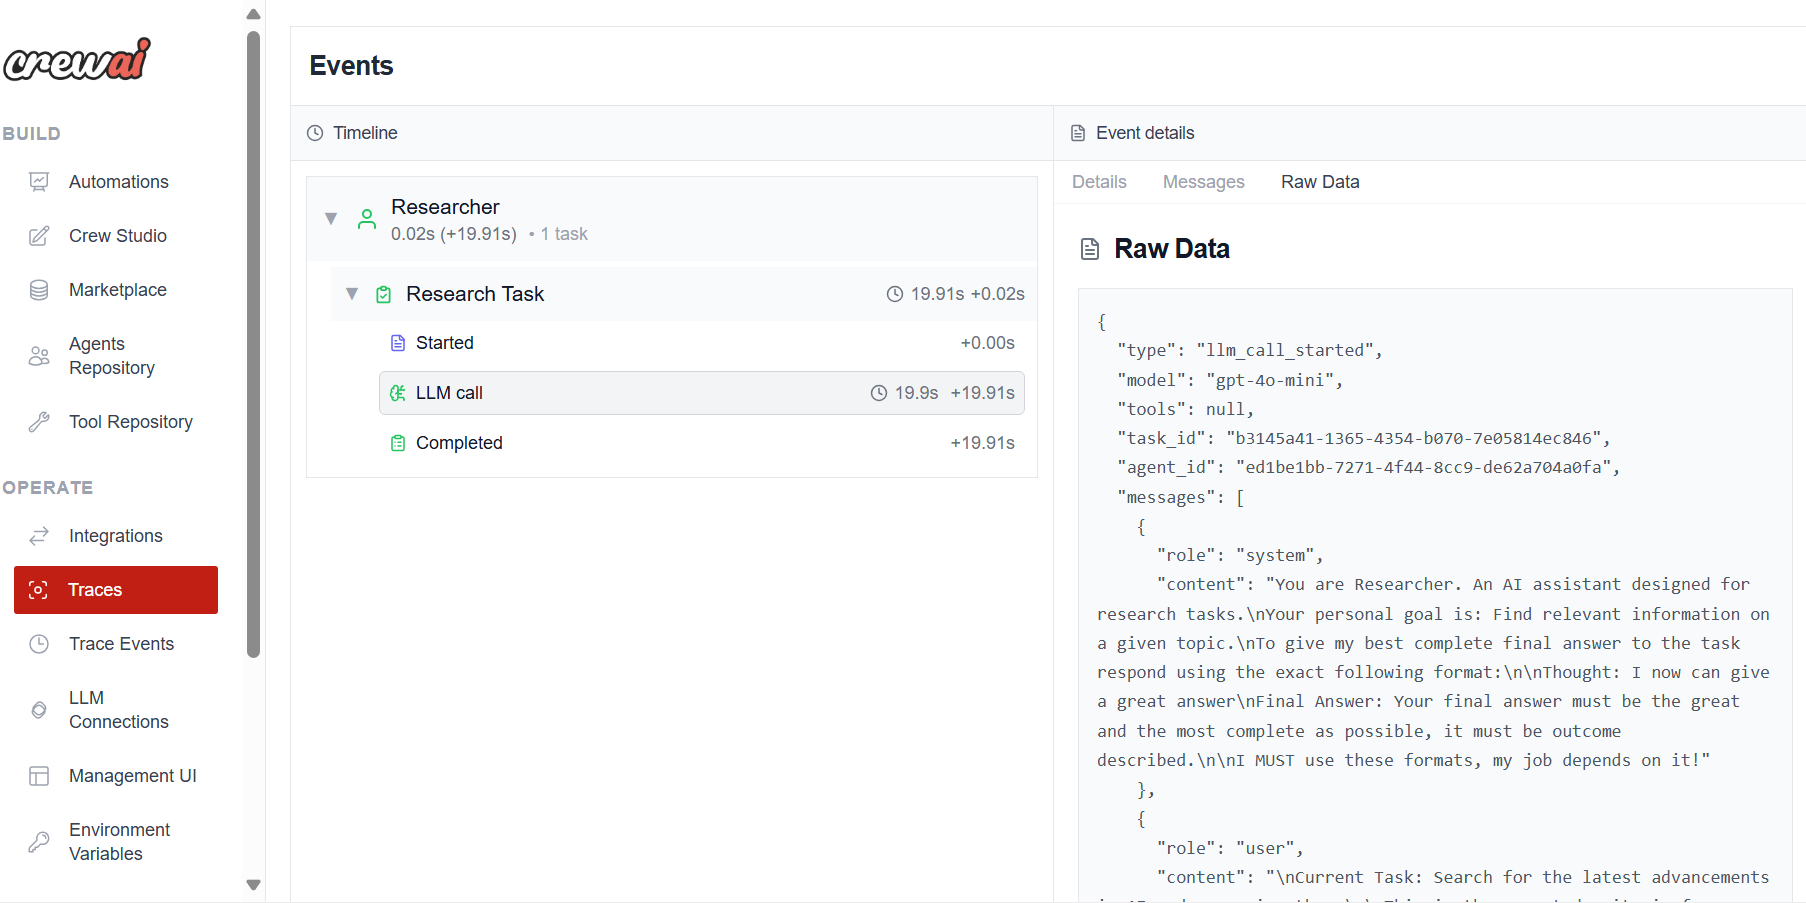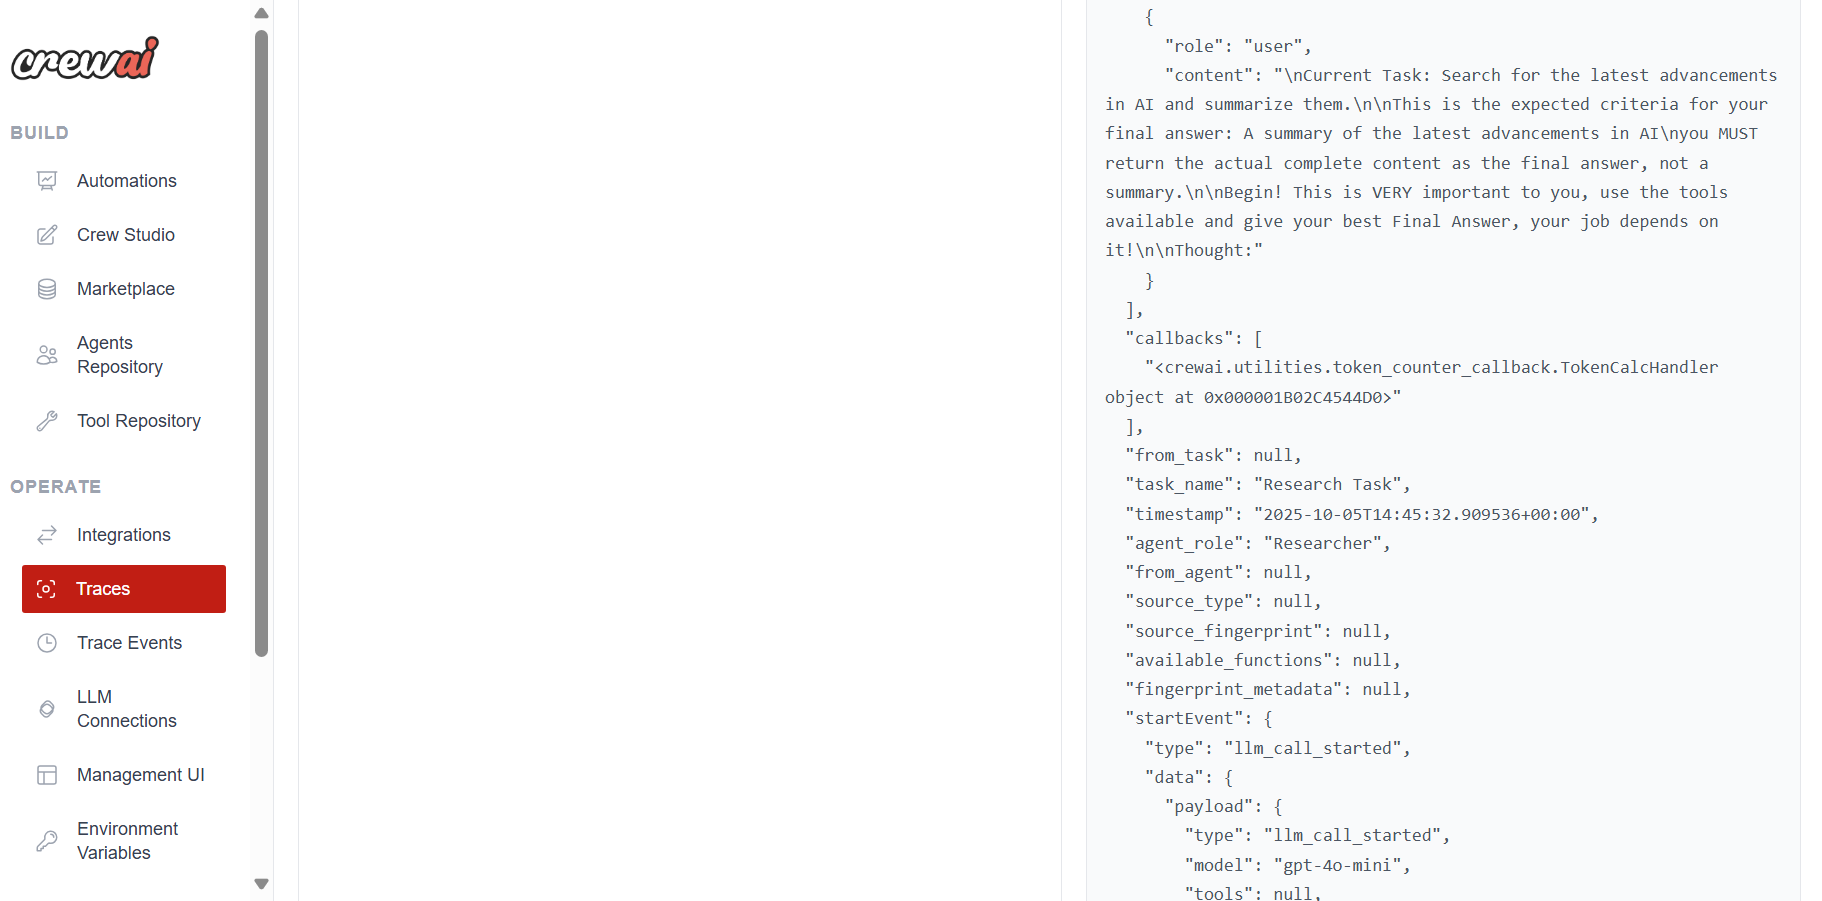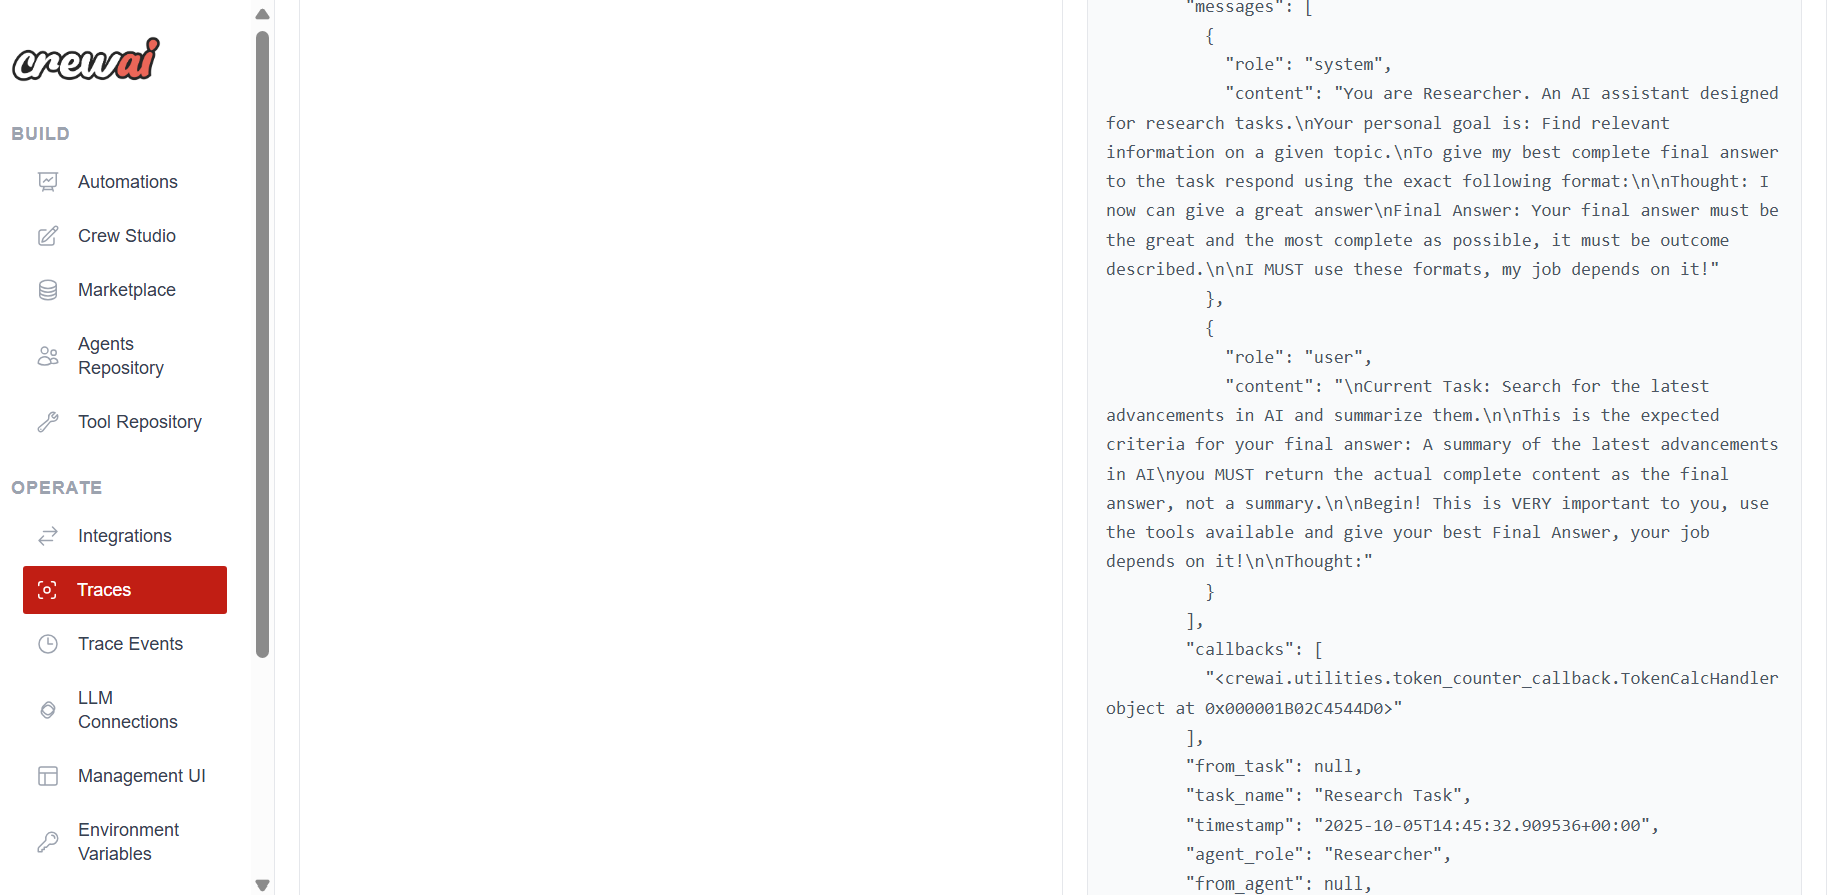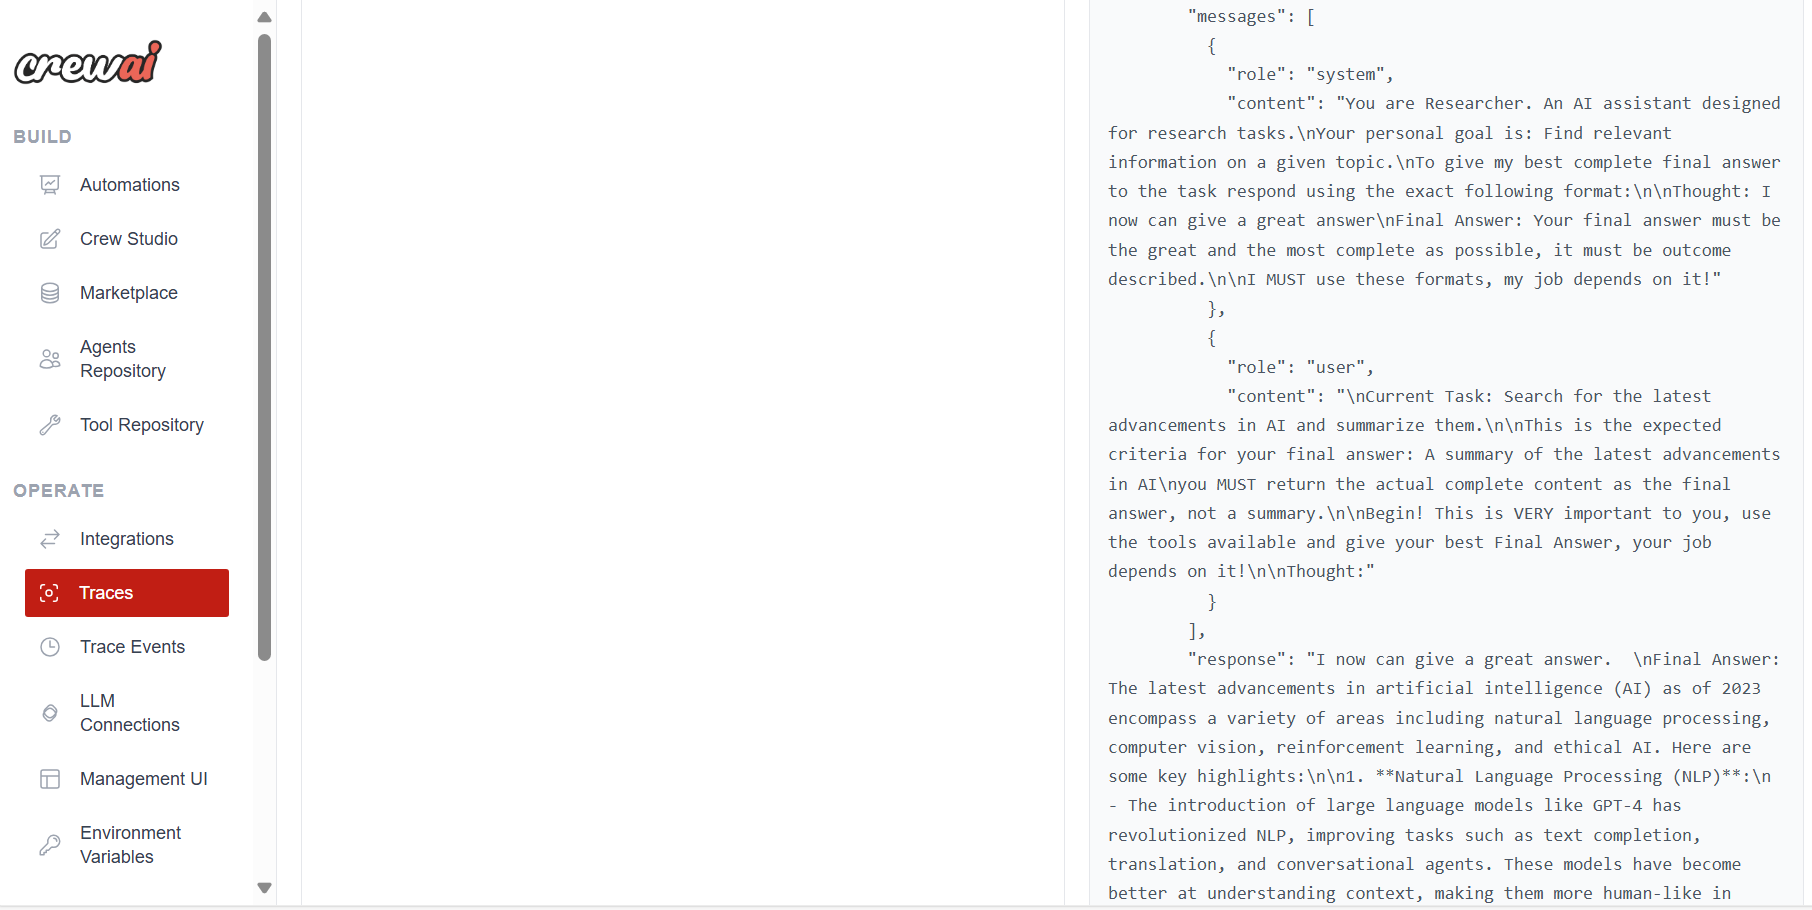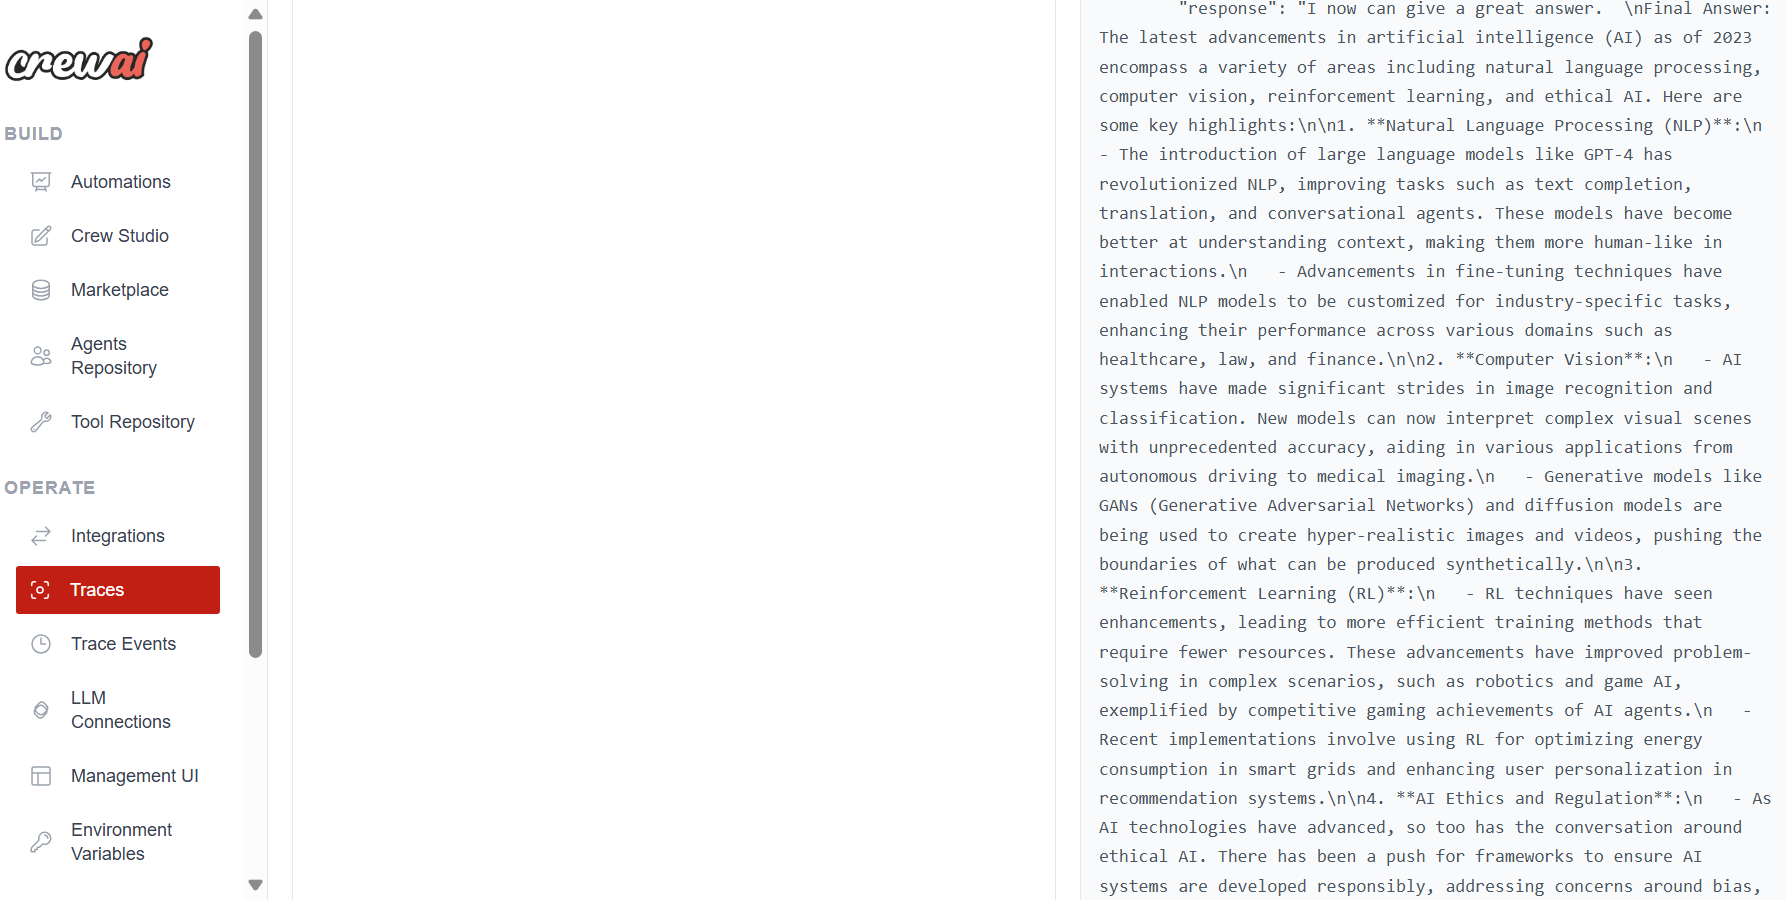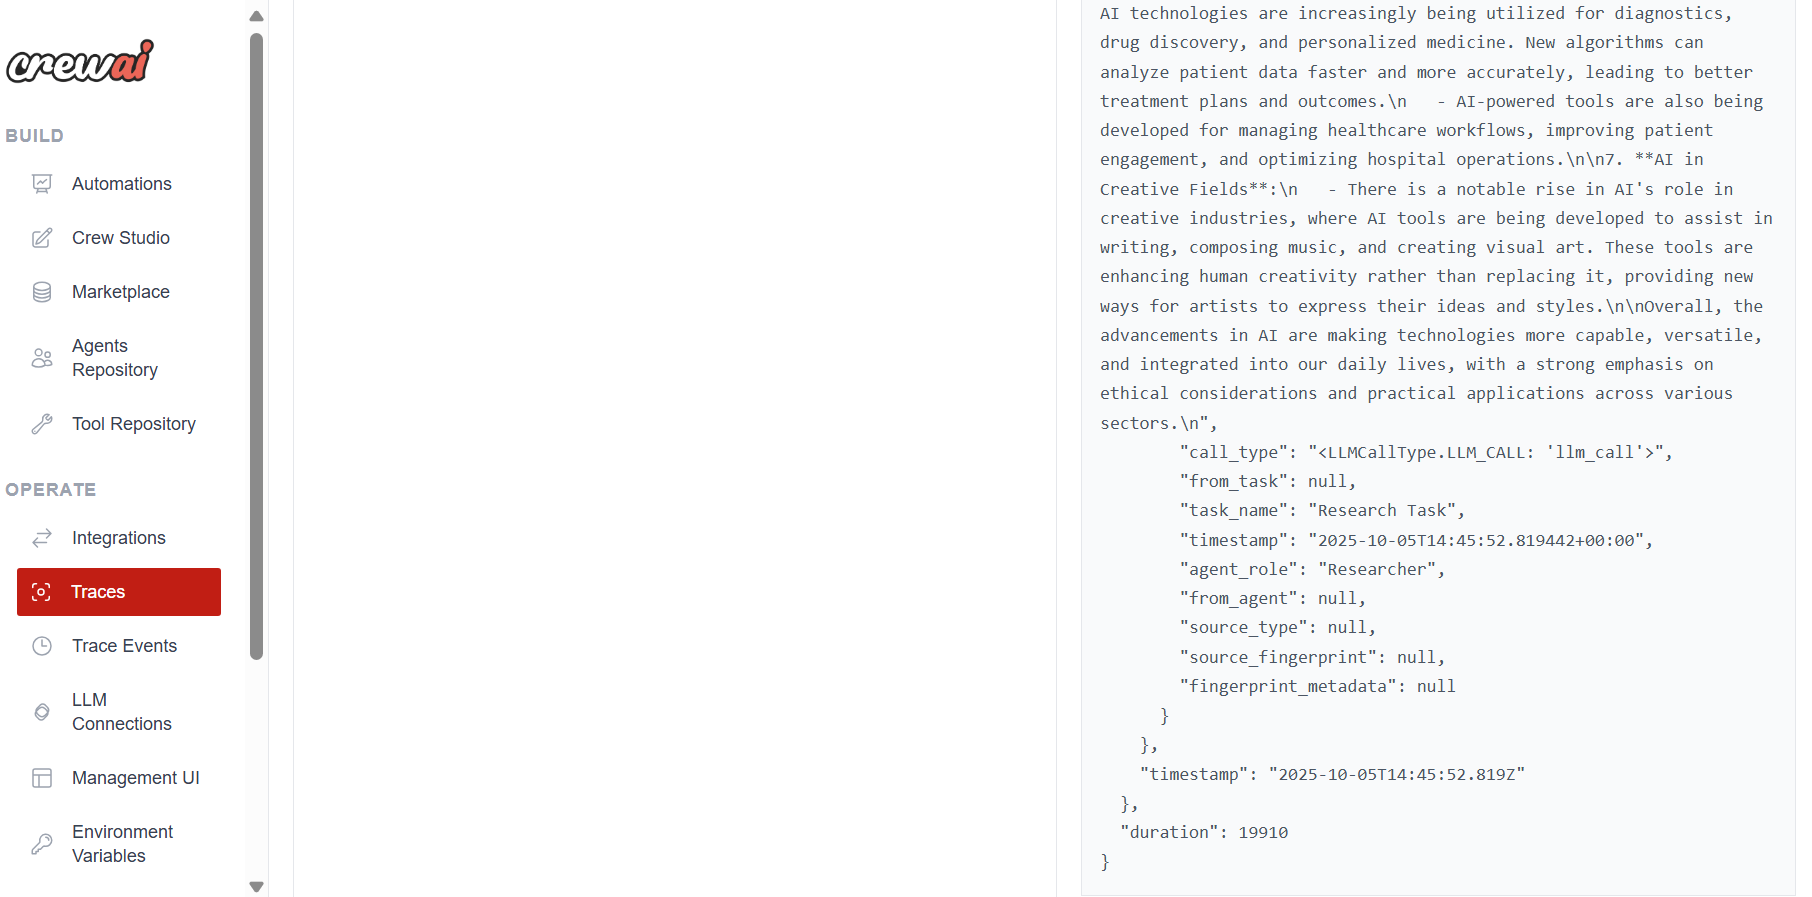

---

### LLM Selection Using `Groq`

In [57]:
from crewai import LLM

llm = LLM(
    model="groq/llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.7
)

llm

In [58]:
# Agent
Agent1 = Agent(
    name="Researcher",
    description="An AI agent that researches and gathers information.",
    goal="Find relevant information on a given topic.",
    role="Researcher", # Added role
    backstory="An AI assistant designed for research tasks.",  # Added backstory
    llm = llm
)

# Task
research_task = Task(
    name="Research Task",
    description="Search for the latest advancements in AI and summarize them.",
    agent=Agent1,
    expected_output="A summary of the latest advancements in AI" # Added expected output
)

# Crew
crew = Crew(
    agents=[agent1], 
    tasks=[research_task]
)

In [59]:
crew.kickoff()

[EventBus Error] Handler 'on_task_started' failed for event 'TaskStartedEvent': 'NoneType' object has no attribute 'key'


c:\Satish\AgenticAI2.0\AgenticAI\my-crewai-venv\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [input_value=UUID('72586e7e-4b0f-4ed6-ac20-547c41fbf3d9'), input_type=UUID])
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [input_value=UUID('d998bf60-2841-46c7-9bd2-3e89622c46f9'), input_type=UUID])
  return self.__pydantic_serializer__.to_python(


╭─────────────────────────────────────────────── Execution Traces ────────────────────────────────────────────────╮
│                                                                                                                 │
│  🔍 Detailed execution traces are available!                                                                    │
│                                                                                                                 │
│  View insights including:                                                                                       │
│    • Agent decision-making process                                                                              │
│    • Task execution flow and timing                                                                             │
│    • Tool usage details                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Would you like to view your execution traces? [y/N] (20s timeout): 

╭─────────────────────────────────────────── Trace Batch Finalization ────────────────────────────────────────────╮
│ ✅ Trace batch finalized with session ID: 278dea0c-059f-436b-8b20-d0b90134892c                                  │
│                                                                                                                 │
│ 🔗 View here:                                                                                                   │
│ https://app.crewai.com/crewai_plus/ephemeral_trace_batches/278dea0c-059f-436b-8b20-d0b90134892c?access_code=TRA │
│ CE-a3977084bd                                                                                                   │
│ 🔑 Access Code: TRACE-a3977084bd                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────── 🔍 Execution Trace Generated ──────────────────────────────────────────╮
│                                                                                                                 │
│  🎉 Your First CrewAI Execution Trace is Ready!                                                                 │
│                                                                                                                 │
│  View your execution details here:                                                                              │
│  https://app.crewai.com/crewai_plus/ephemeral_trace_batches/278dea0c-059f-436b-8b20-d0b90134892c?access_code=T  │
│  RACE-a3977084bd                                                                                                │
│                                                                                                                 │
│  This trace shows:                                                                                              │
│  • Agent decisions and interactions                                                                             │
│  • Task execution timeline                                                                                      │
│  • Tool usage and results                                                                                       │
│  • LLM calls and responses                                                                                      │
│                                                                                                                 │
│  ✅ Tracing has been enabled for future runs! (CREWAI_TRACING_ENABLED=true added to .env)                       │
│  You can also add tracing=True to your Crew(tracing=True) / Flow(tracing=True) for more control.                │
│                                                                                                                 │
│  📝 Note: This link will expire in 24 hours.                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

CrewOutput(raw='The latest advancements in Artificial Intelligence (AI) have been rapid and multifaceted, transforming various sectors and revolutionizing the way we live and work. Some of the key developments include:\n\n1. **Deep Learning**: Significant improvements have been made in deep learning techniques, enabling AI systems to learn from vast amounts of data, recognize patterns, and make predictions with unprecedented accuracy. This has led to breakthroughs in image and speech recognition, natural language processing, and decision-making.\n\n2. **Natural Language Processing (NLP)**: NLP has seen tremendous growth, with AI models like Transformers and BERT achieving state-of-the-art results in language understanding, generation, and translation. This has enabled the development of more sophisticated chatbots, virtual assistants, and language translation systems.\n\n3. **Explainable AI (XAI)**: As AI becomes more pervasive, there is a growing need to understand how AI systems make

HTTPSConnectionPool(host='telemetry.crewai.com', port=4319): Max retries exceeded with url: /v1/traces (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x000001B02D188410>, 'Connection to telemetry.crewai.com timed out. (connect timeout=29.99999690055847)'))


### Traces
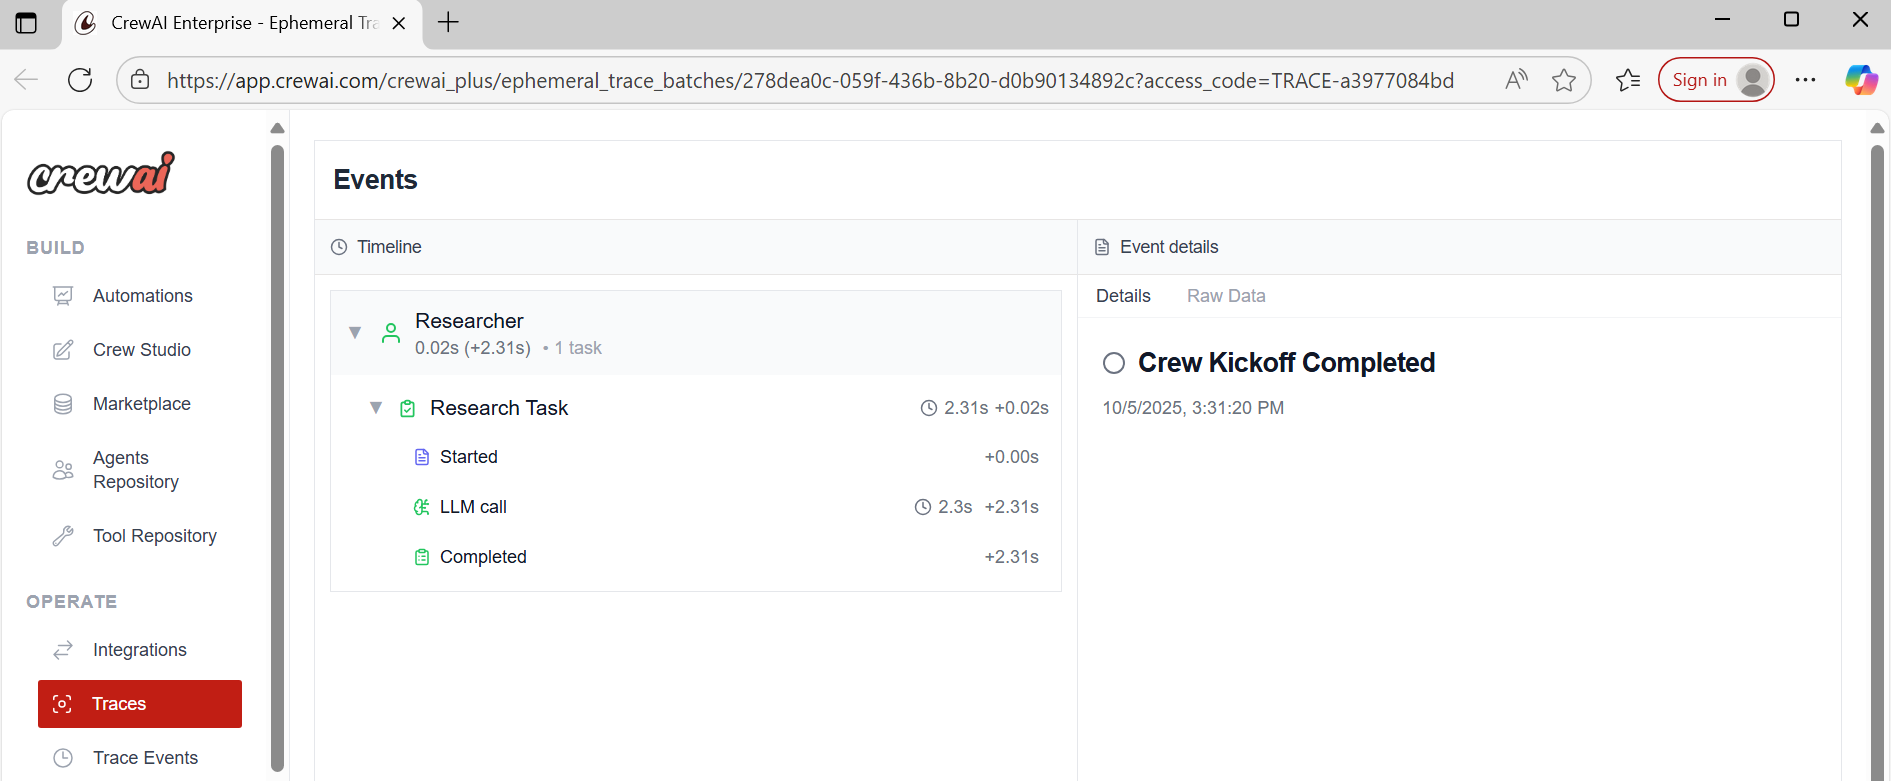 <br><br>
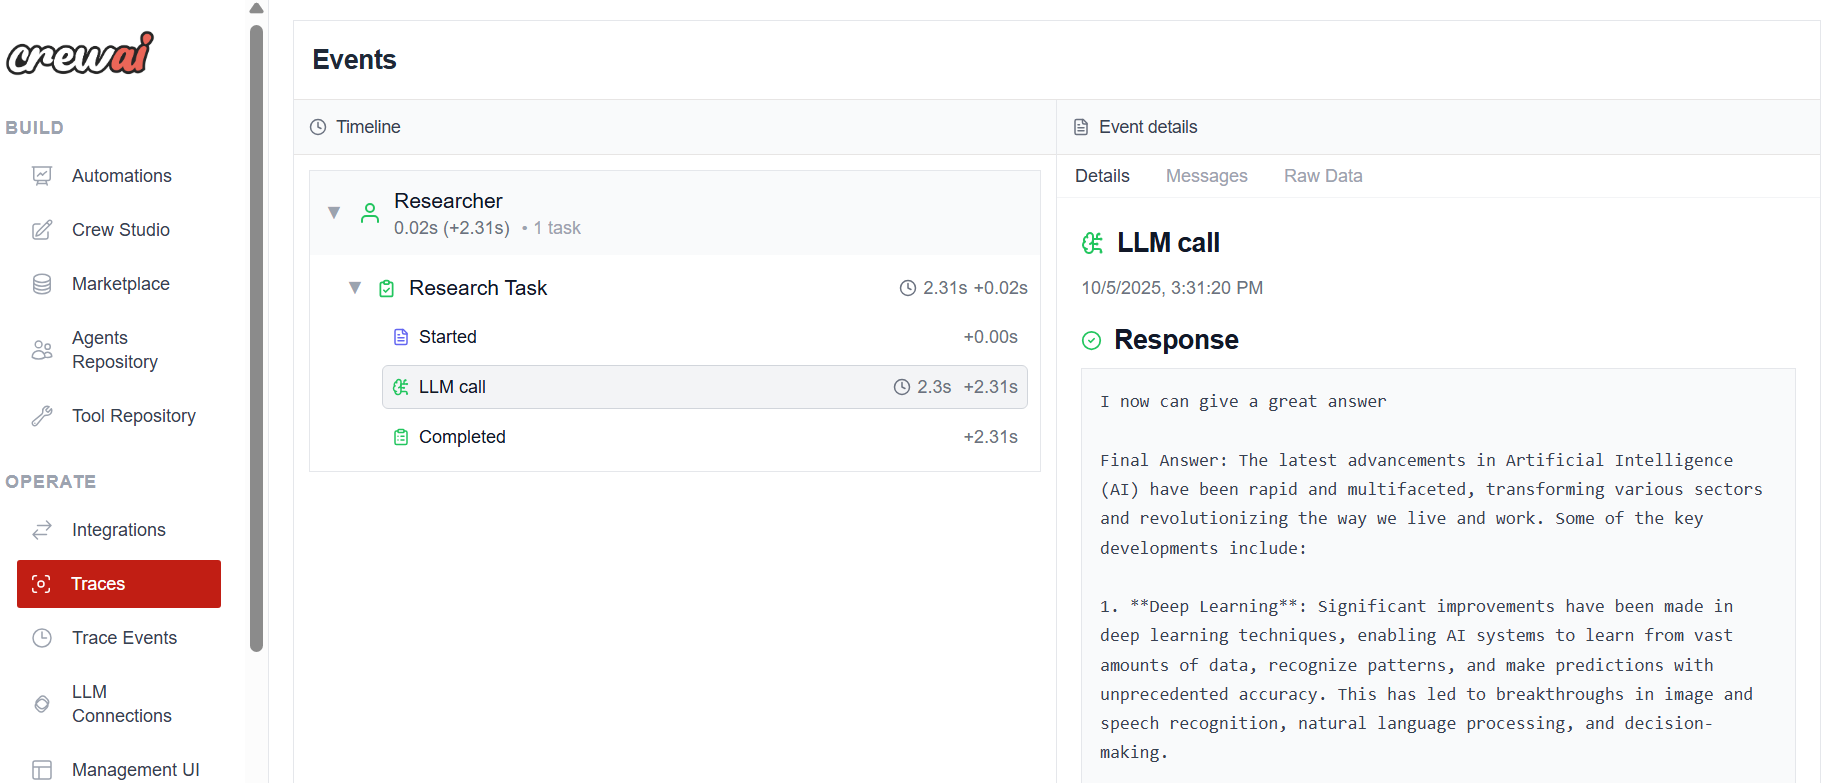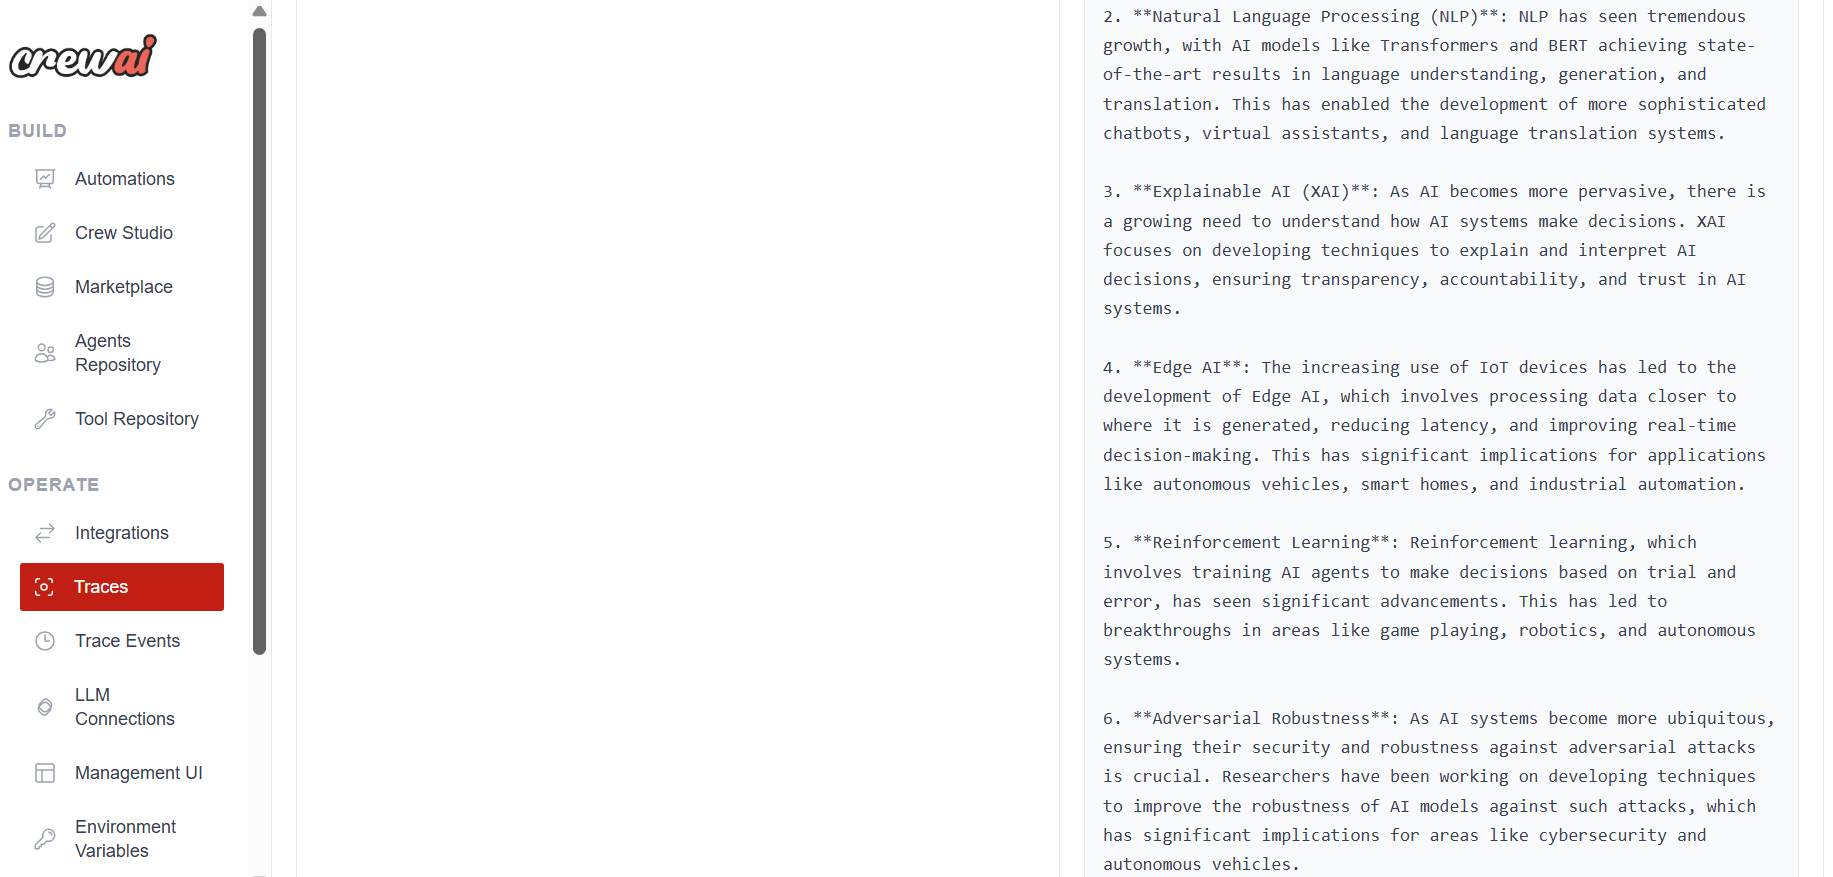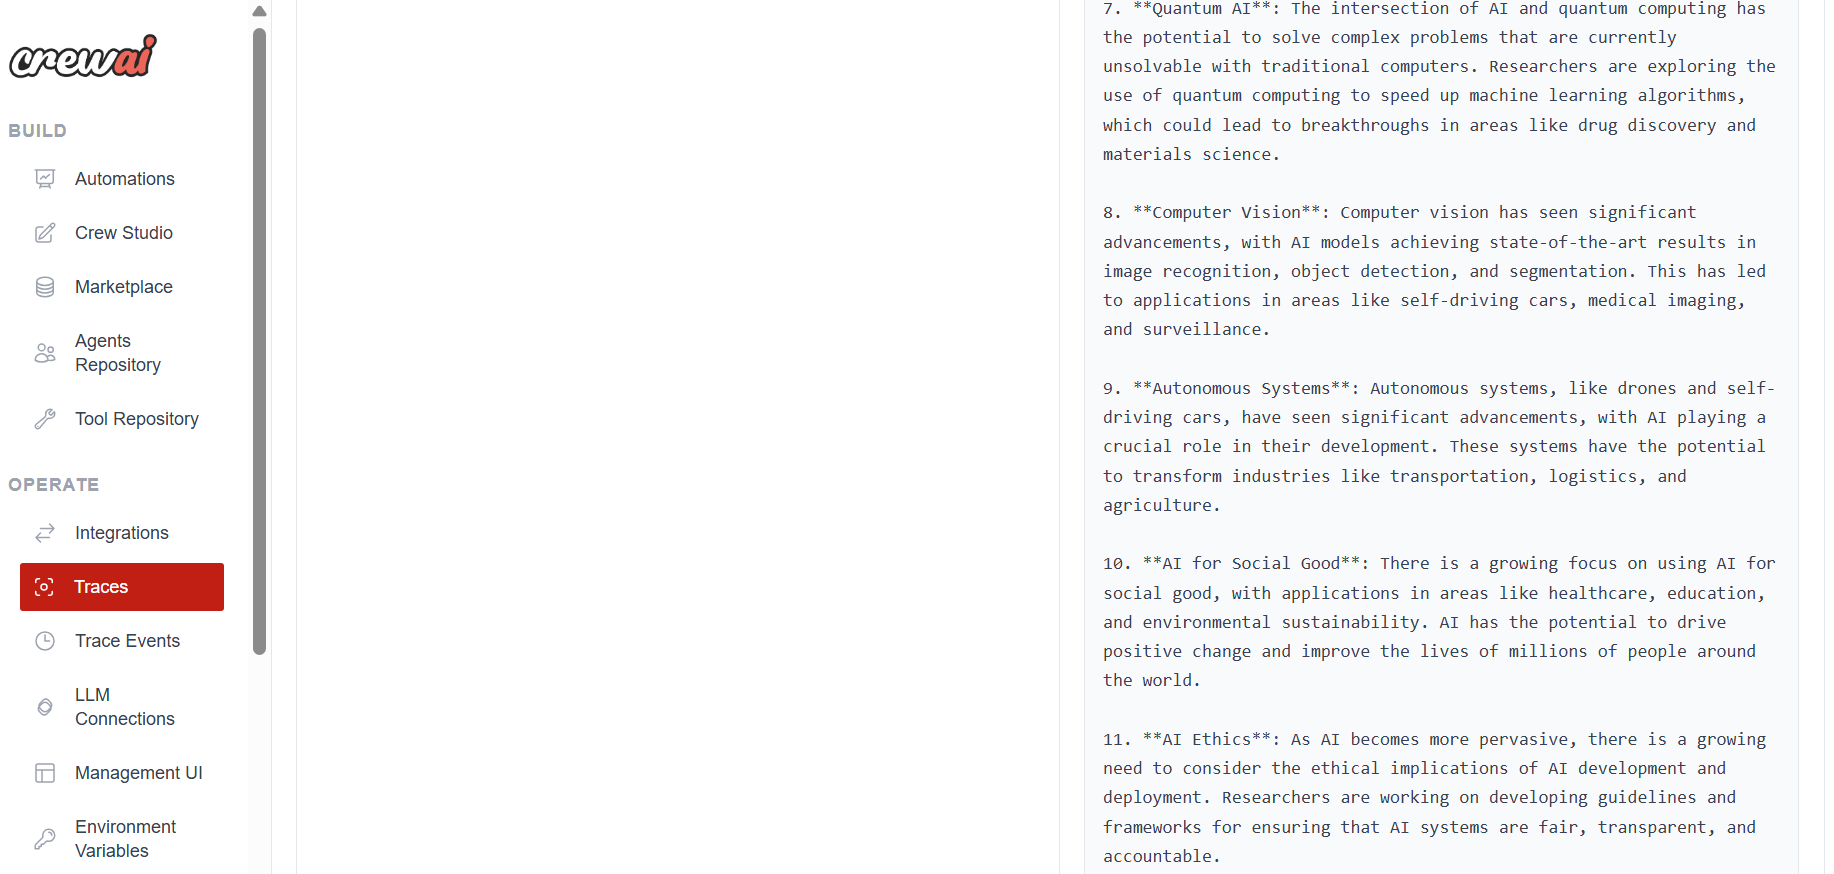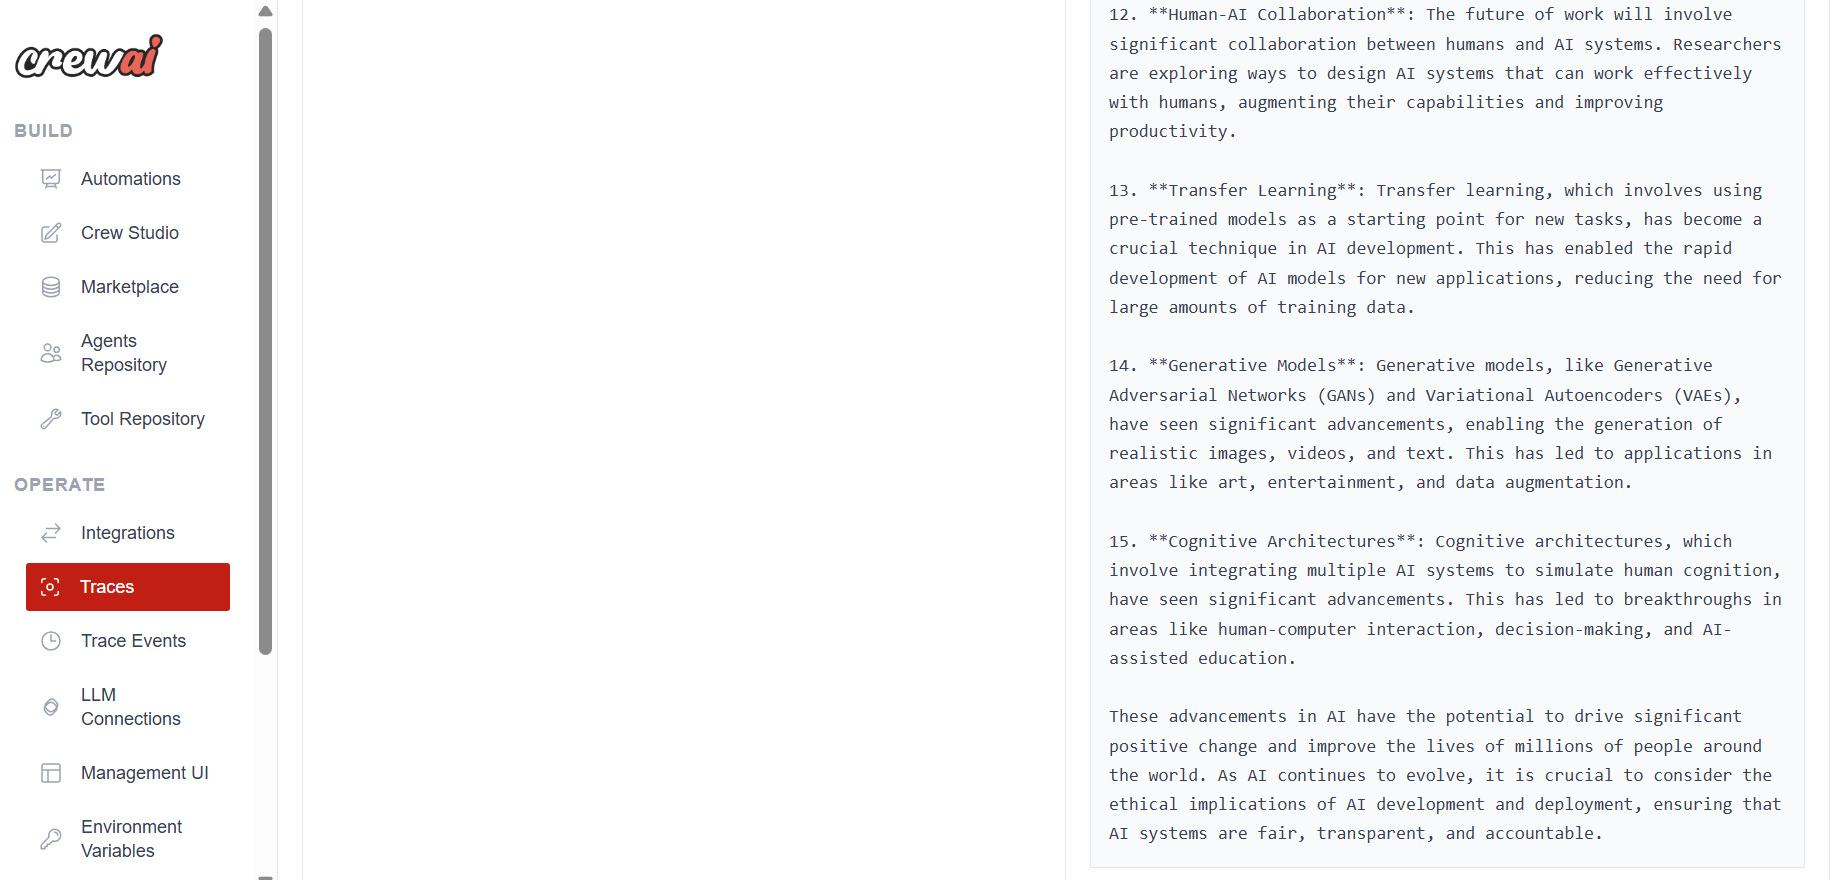 <br><br>
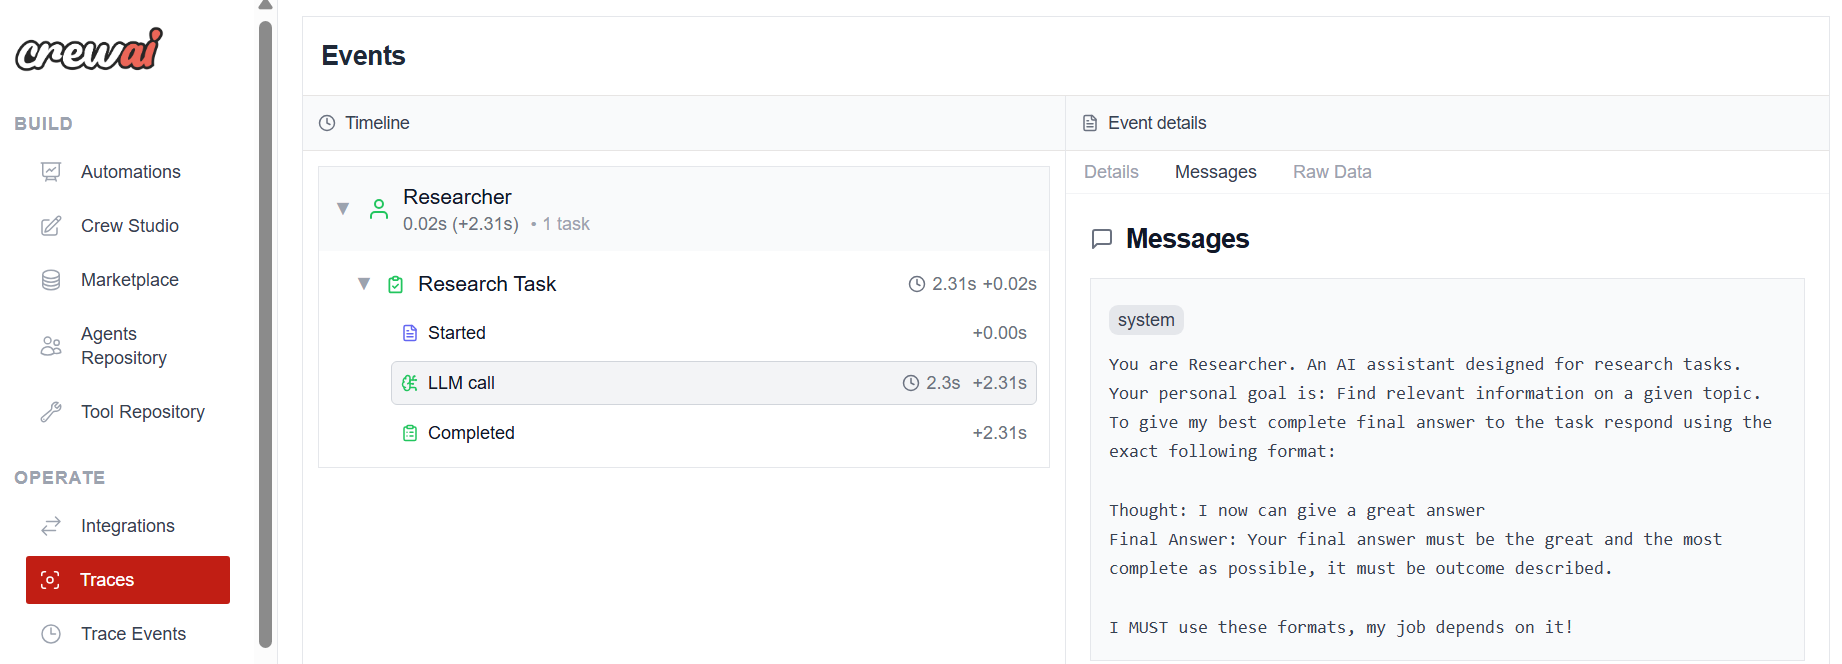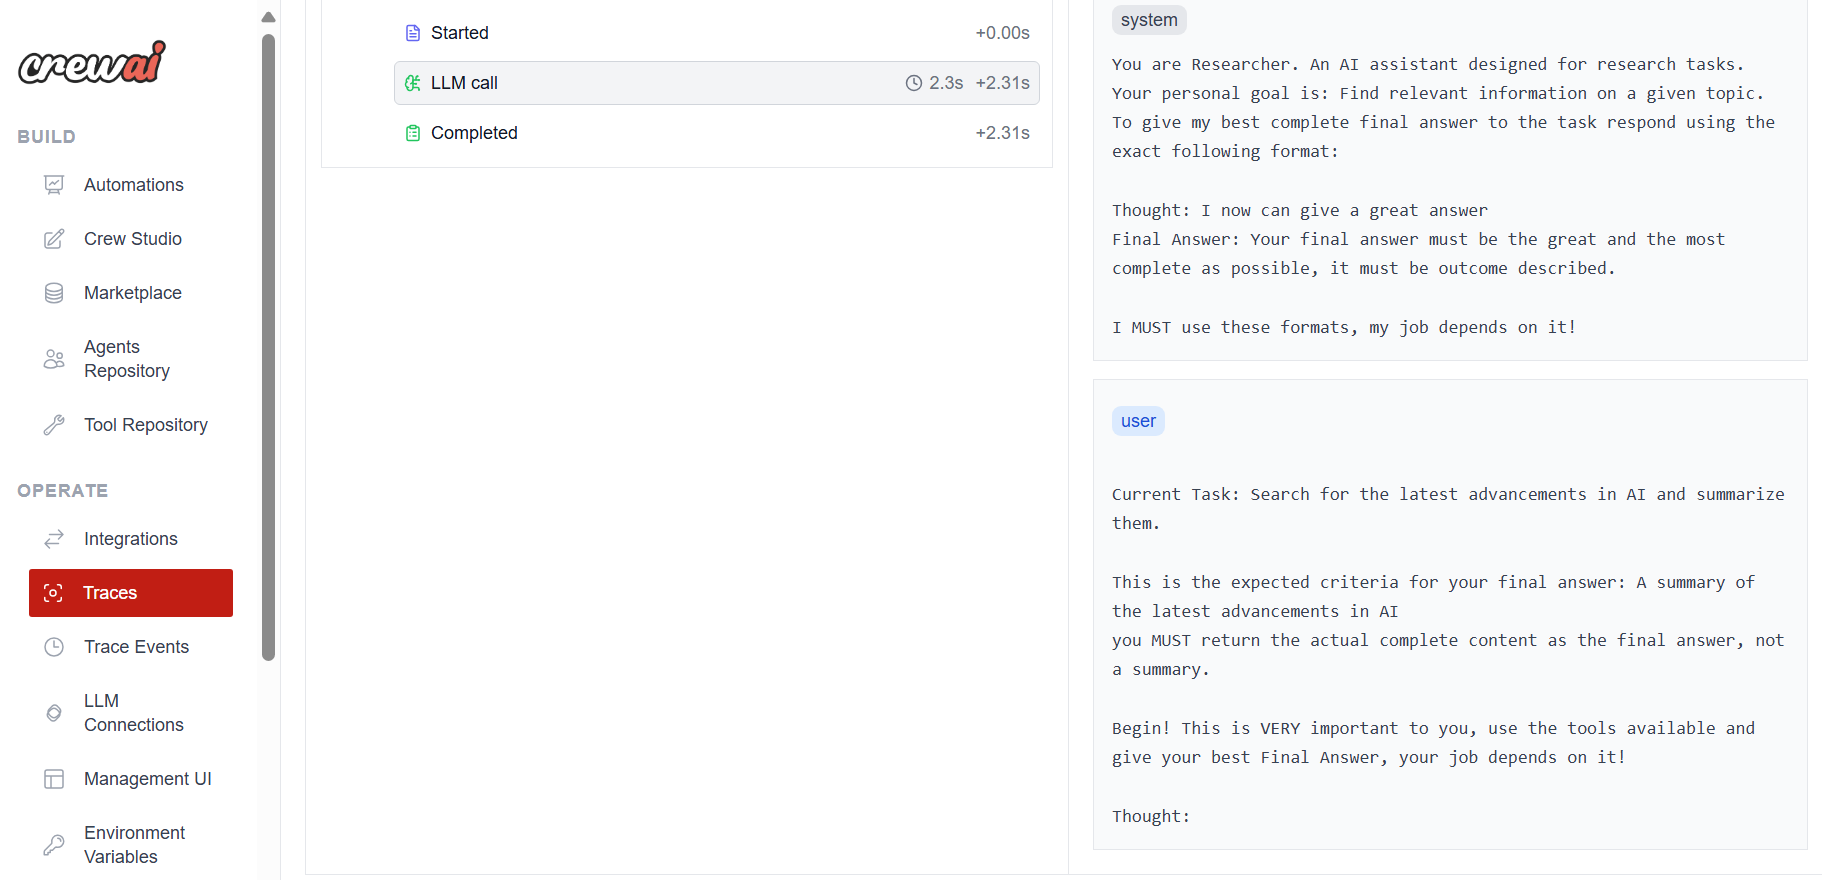 <br><br>
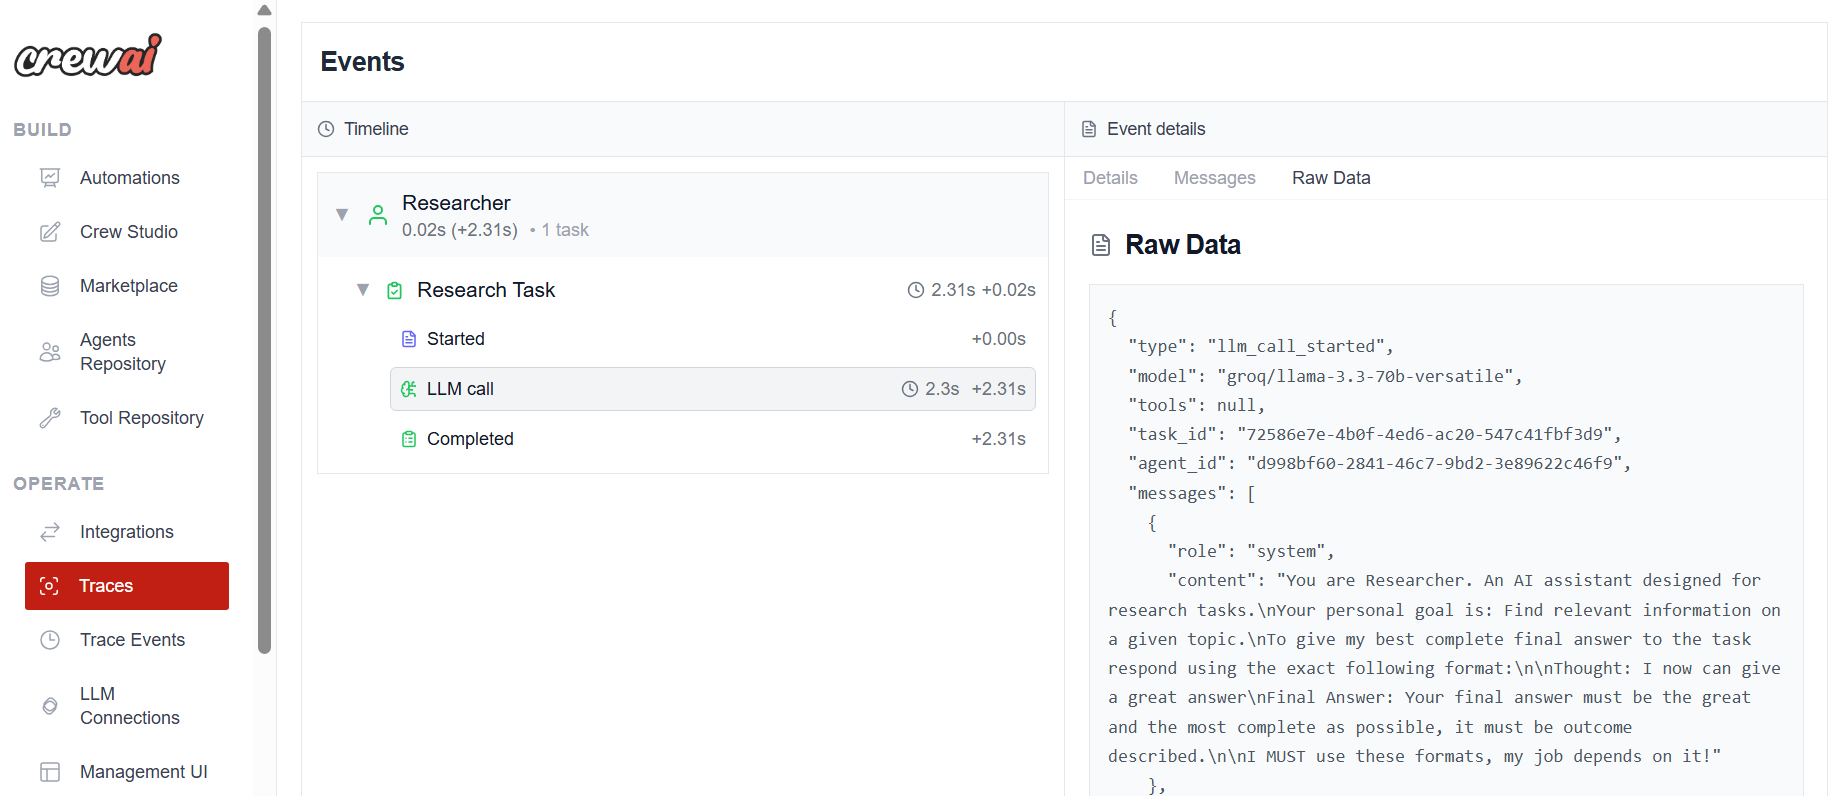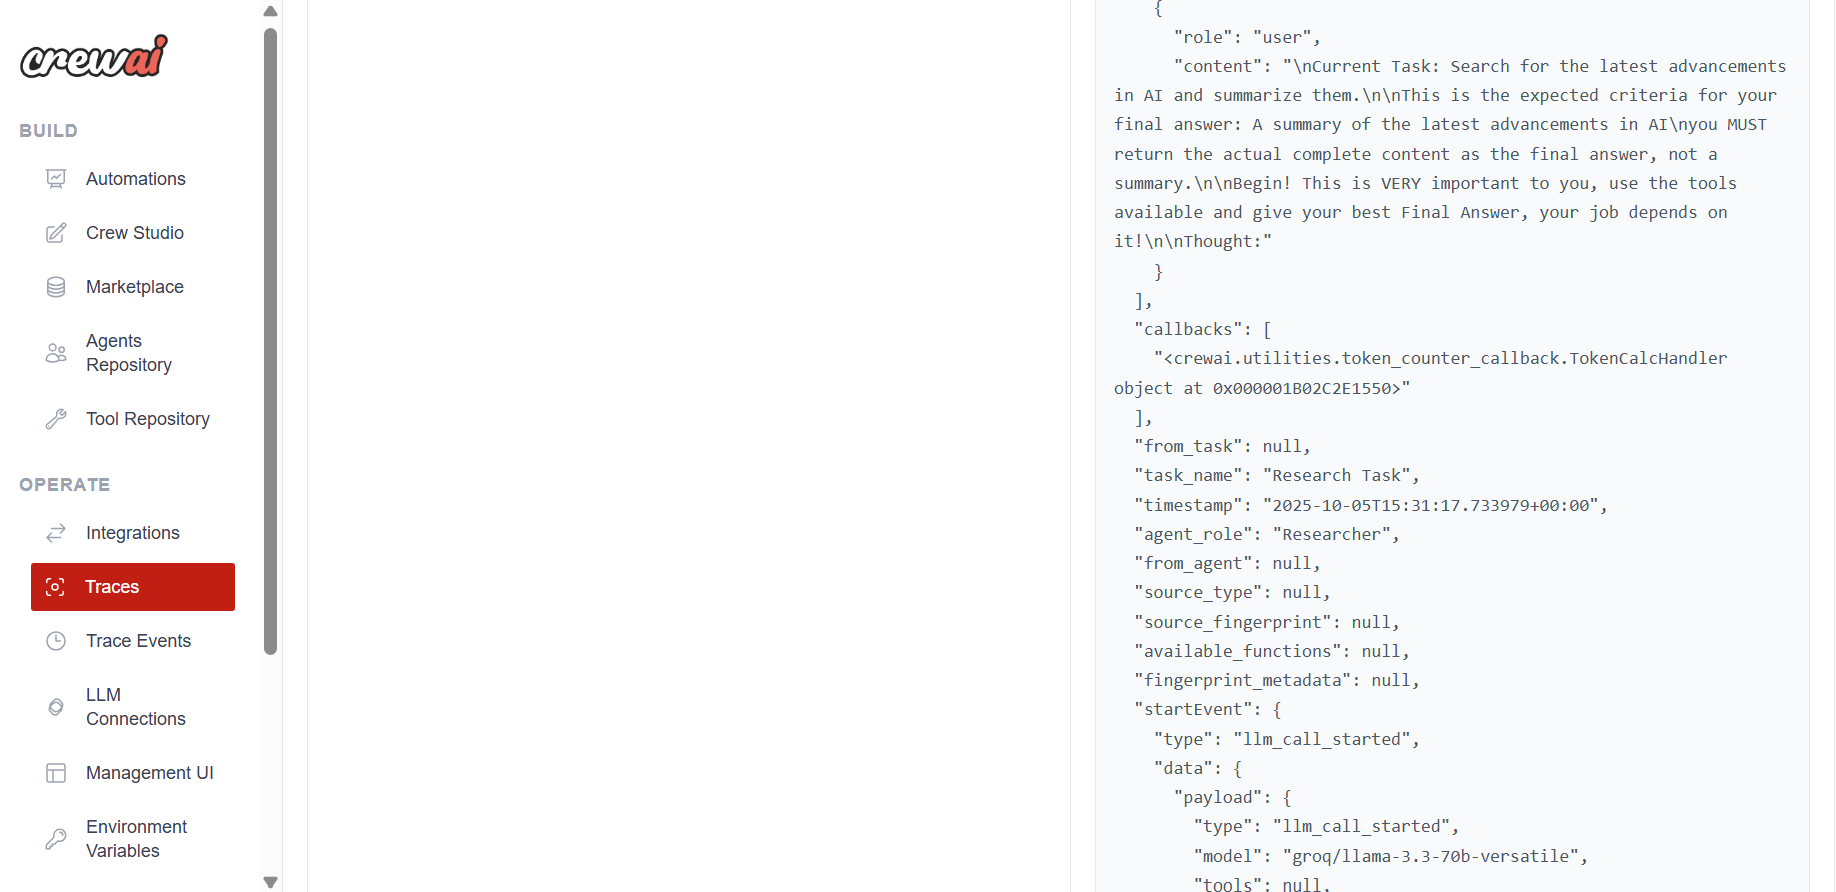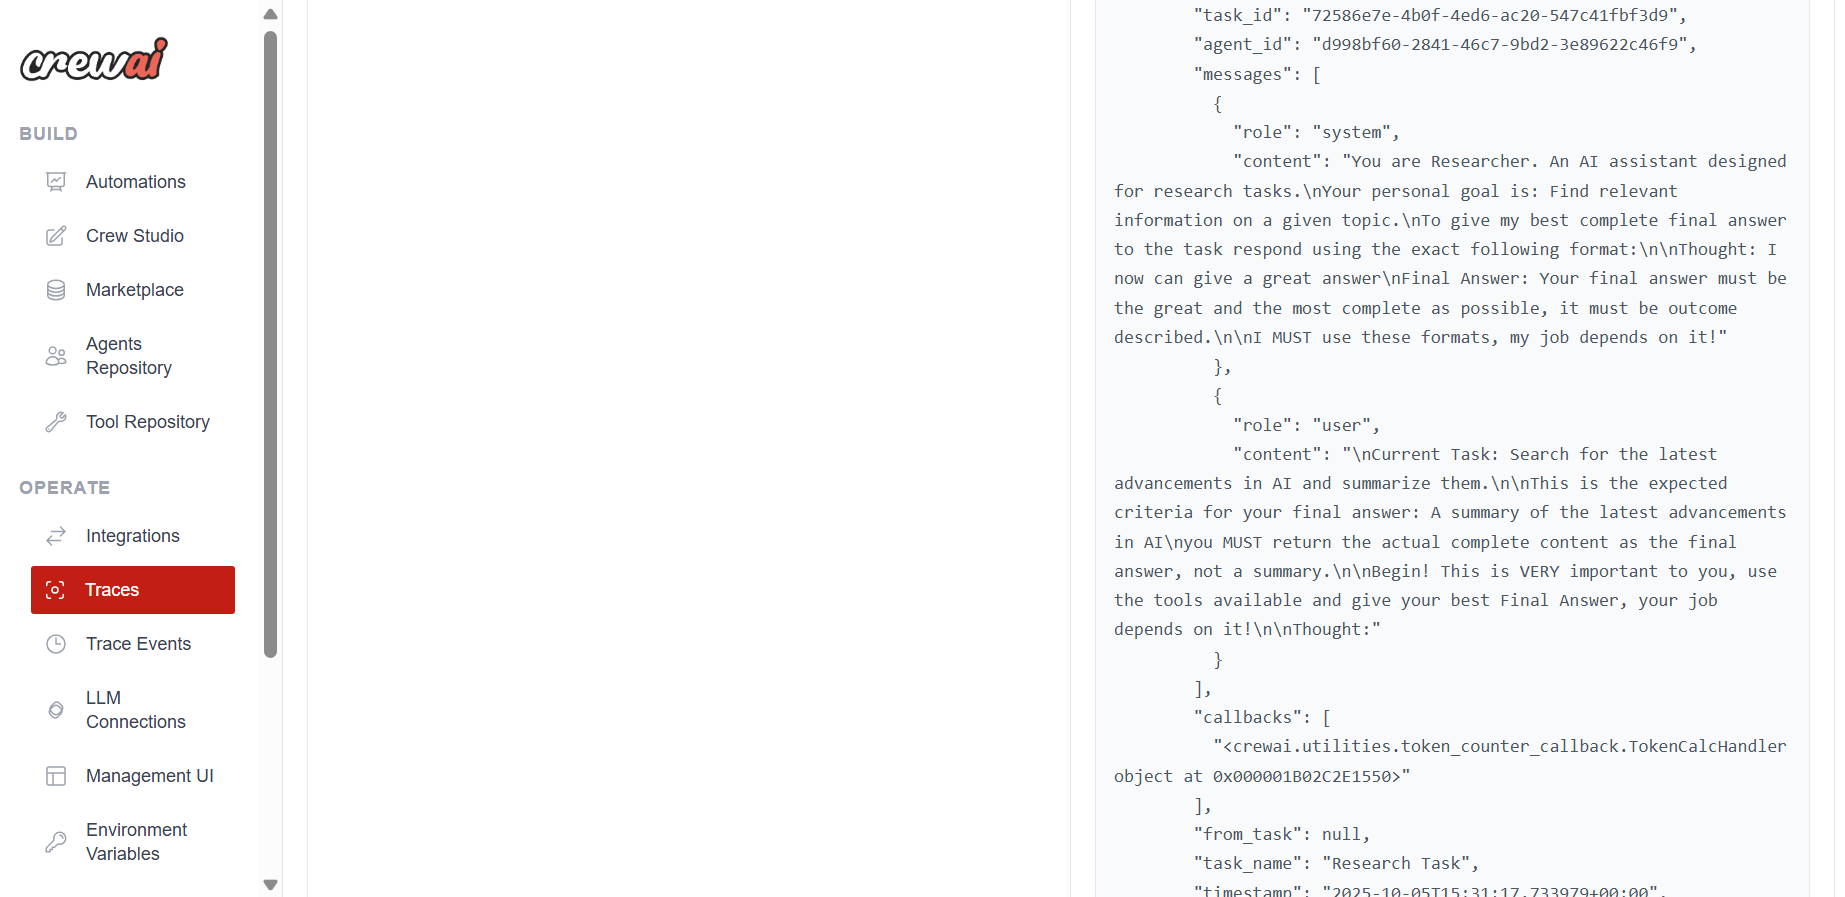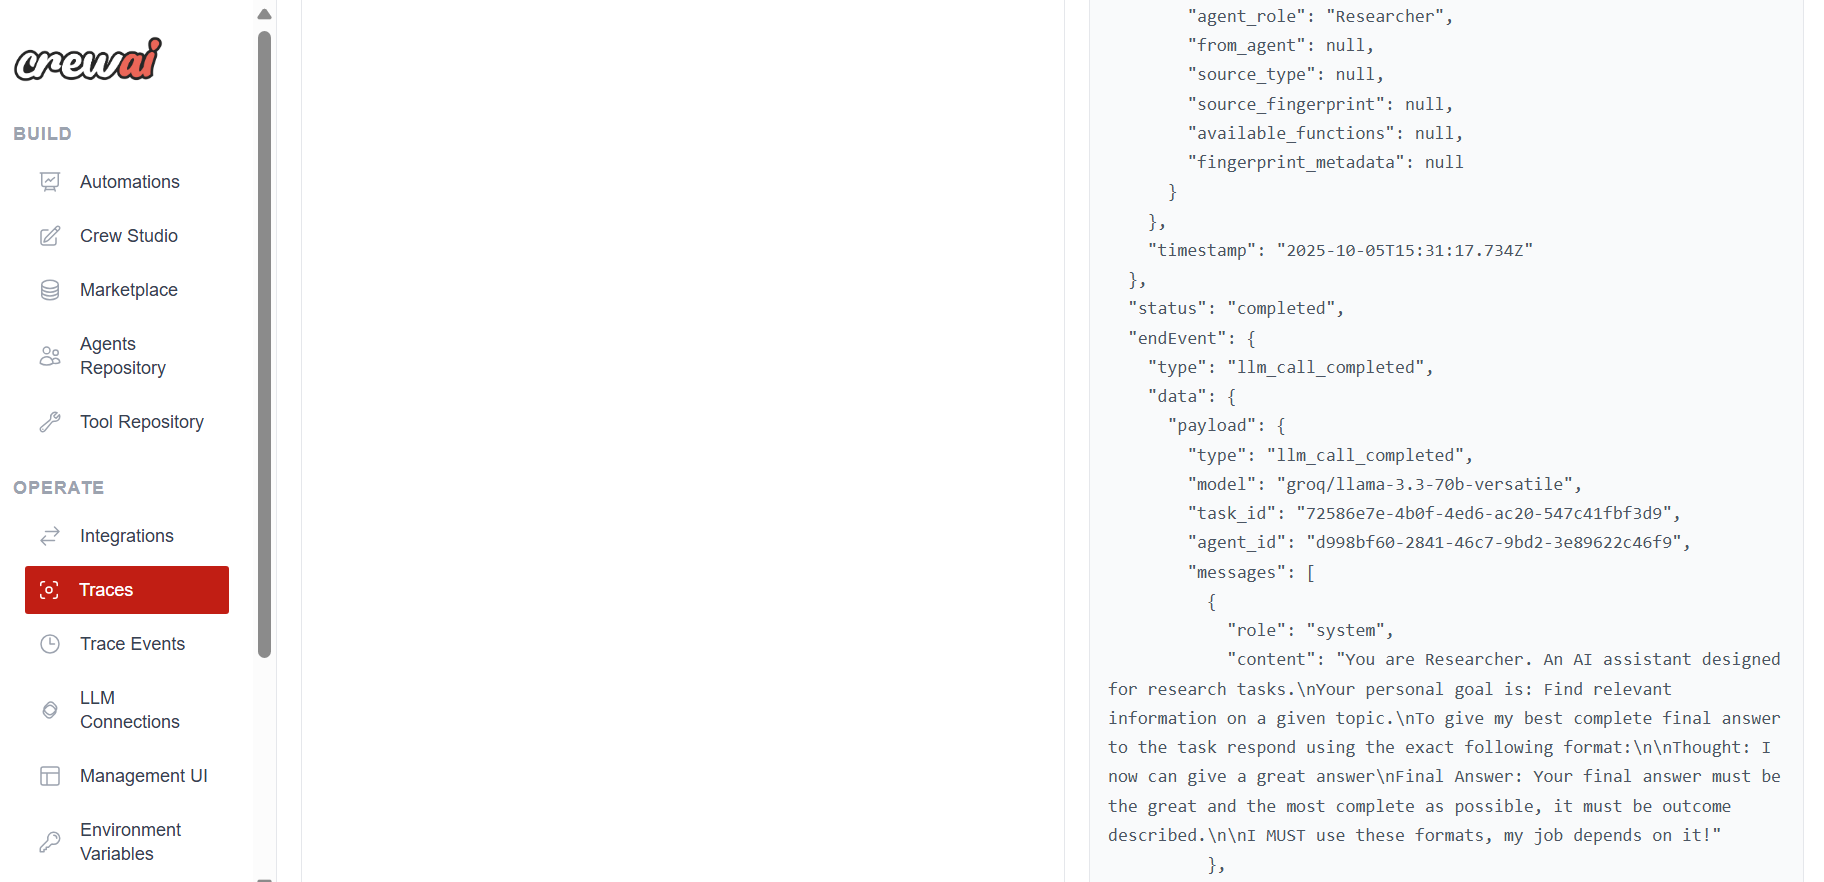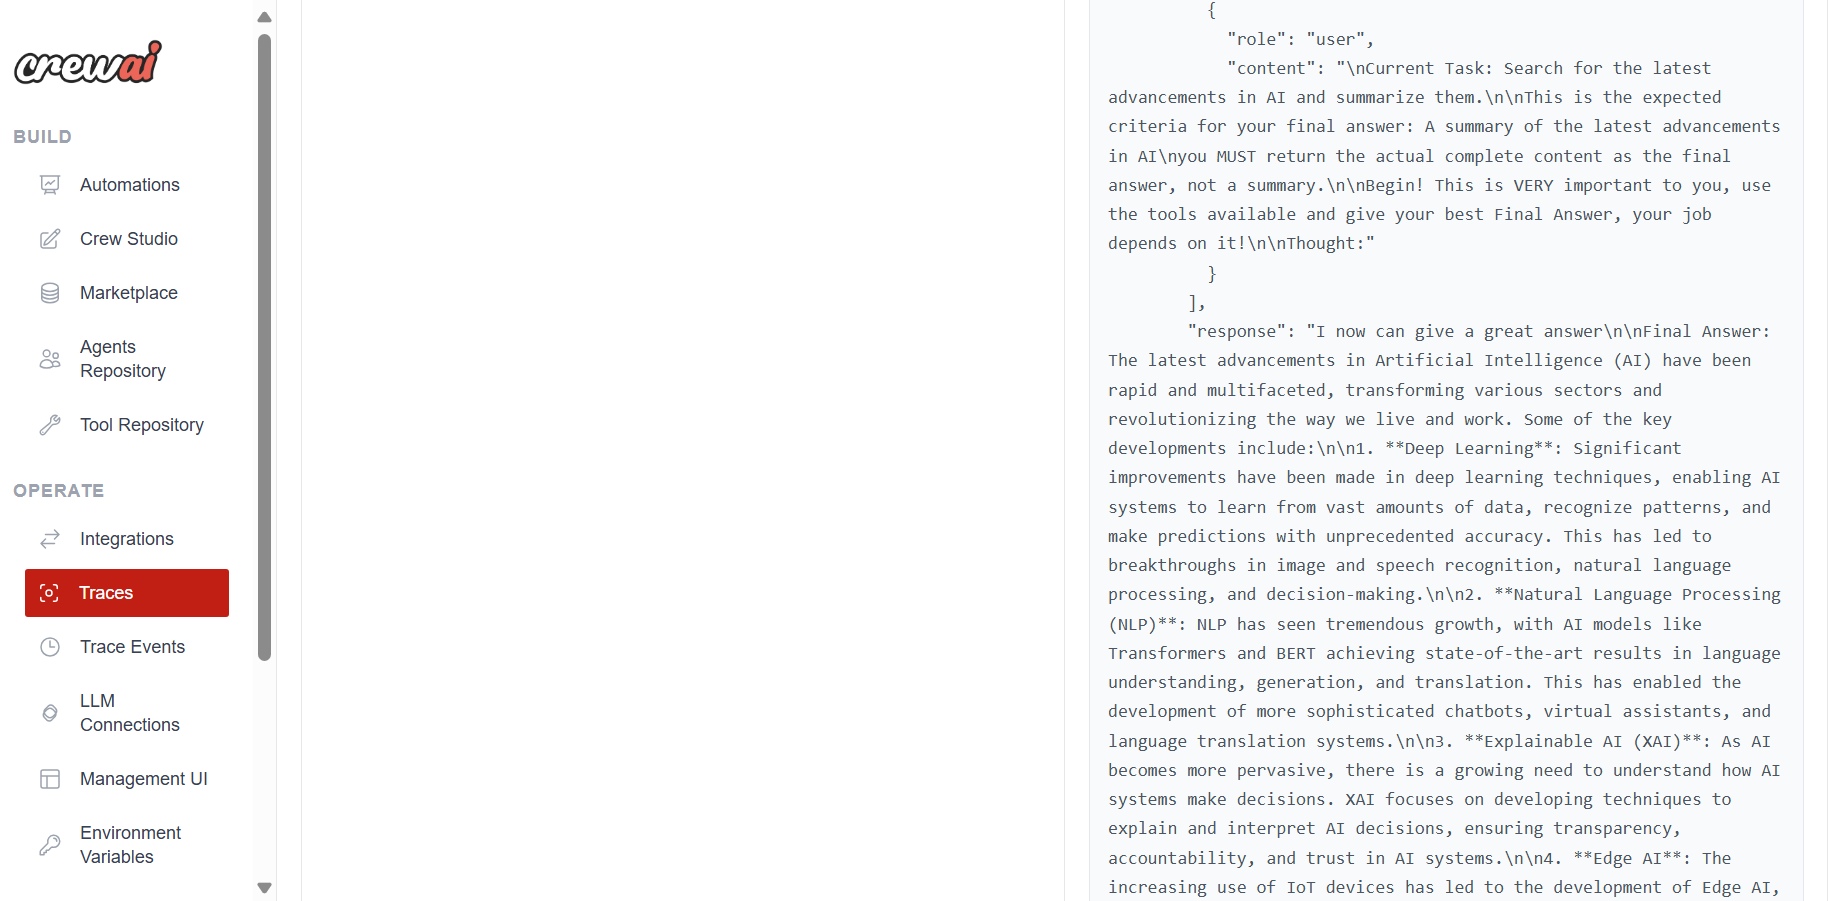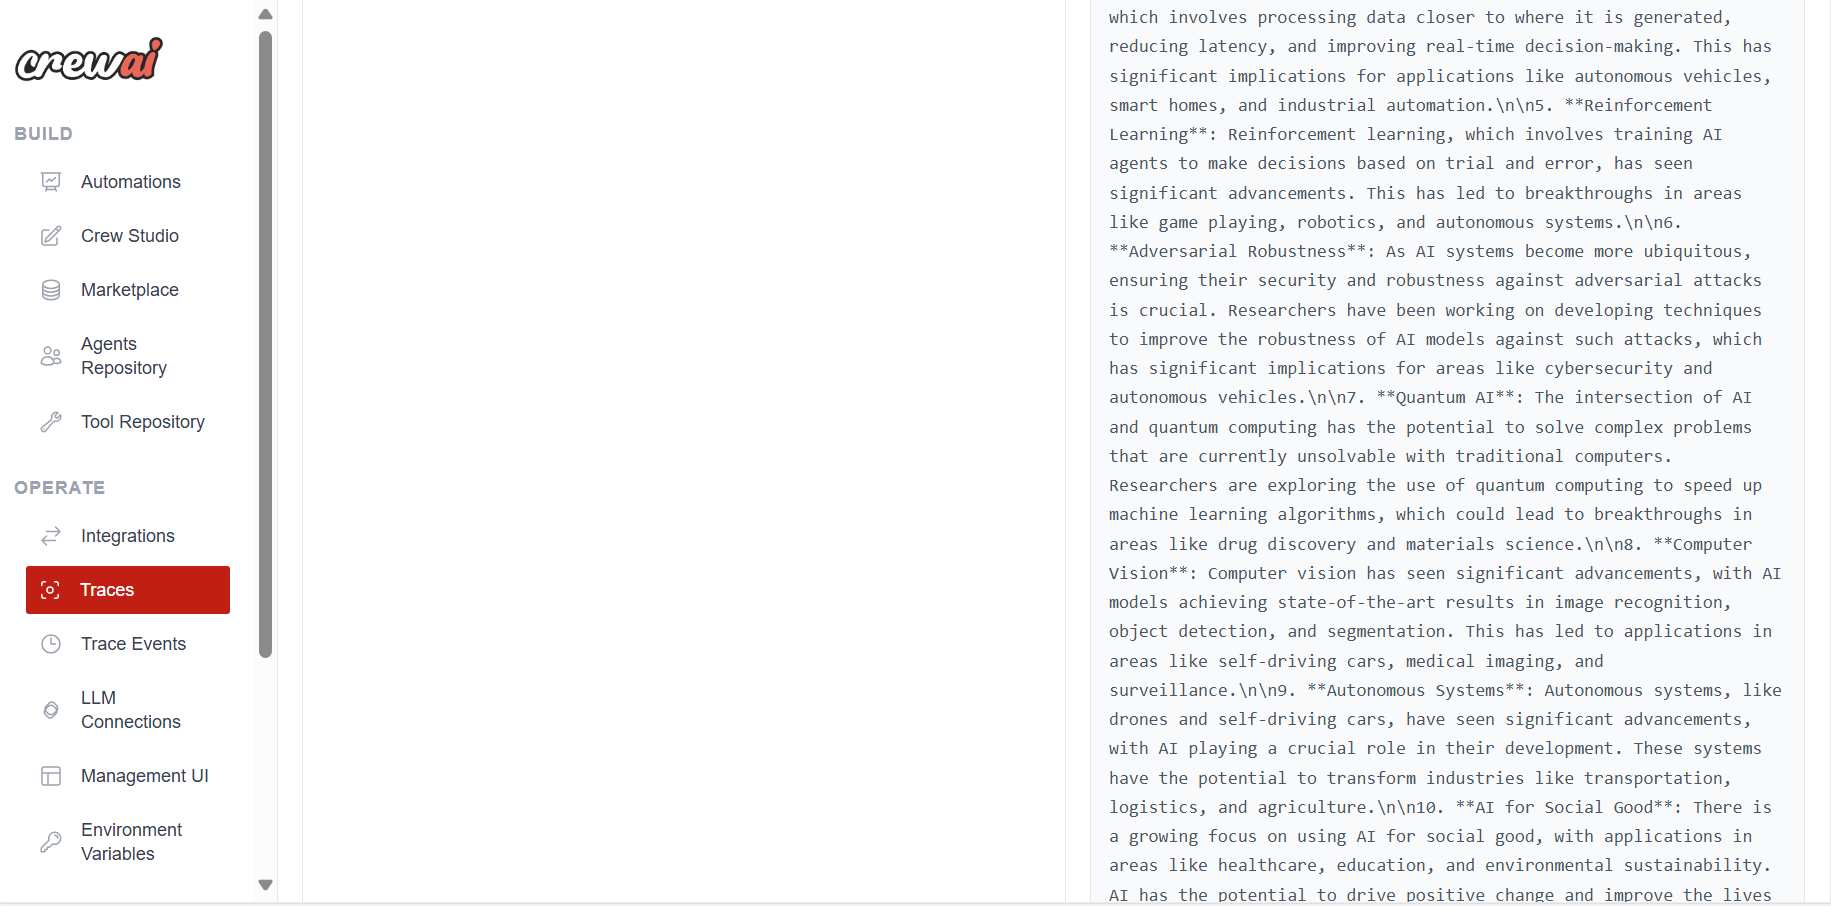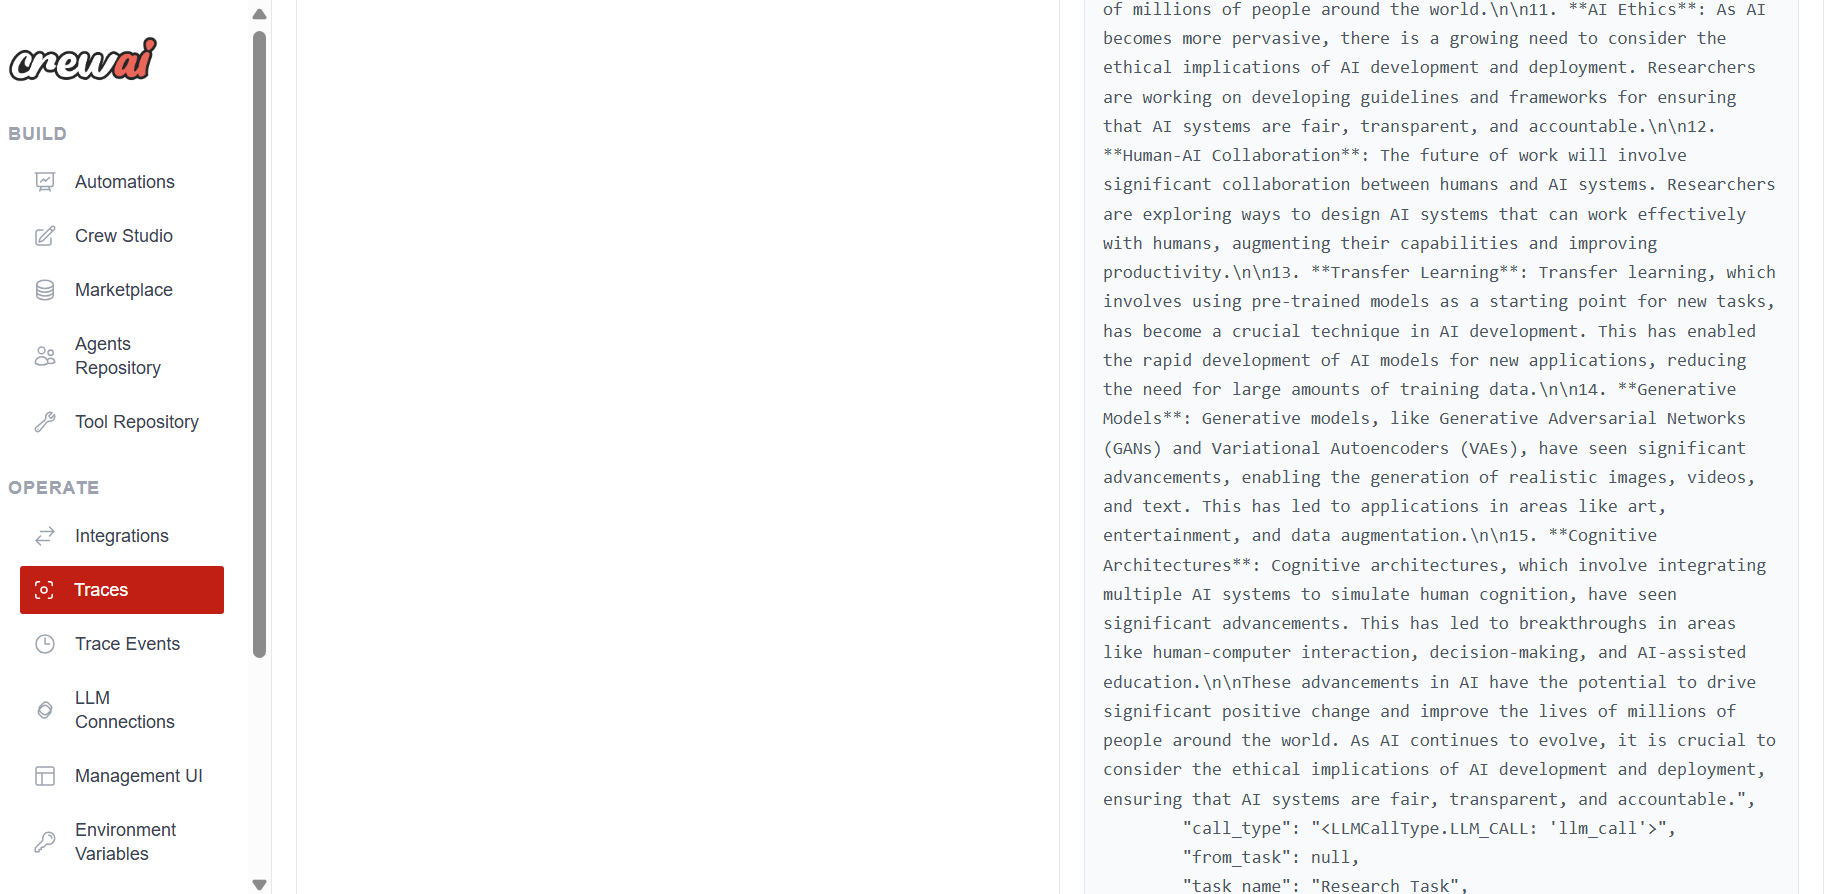
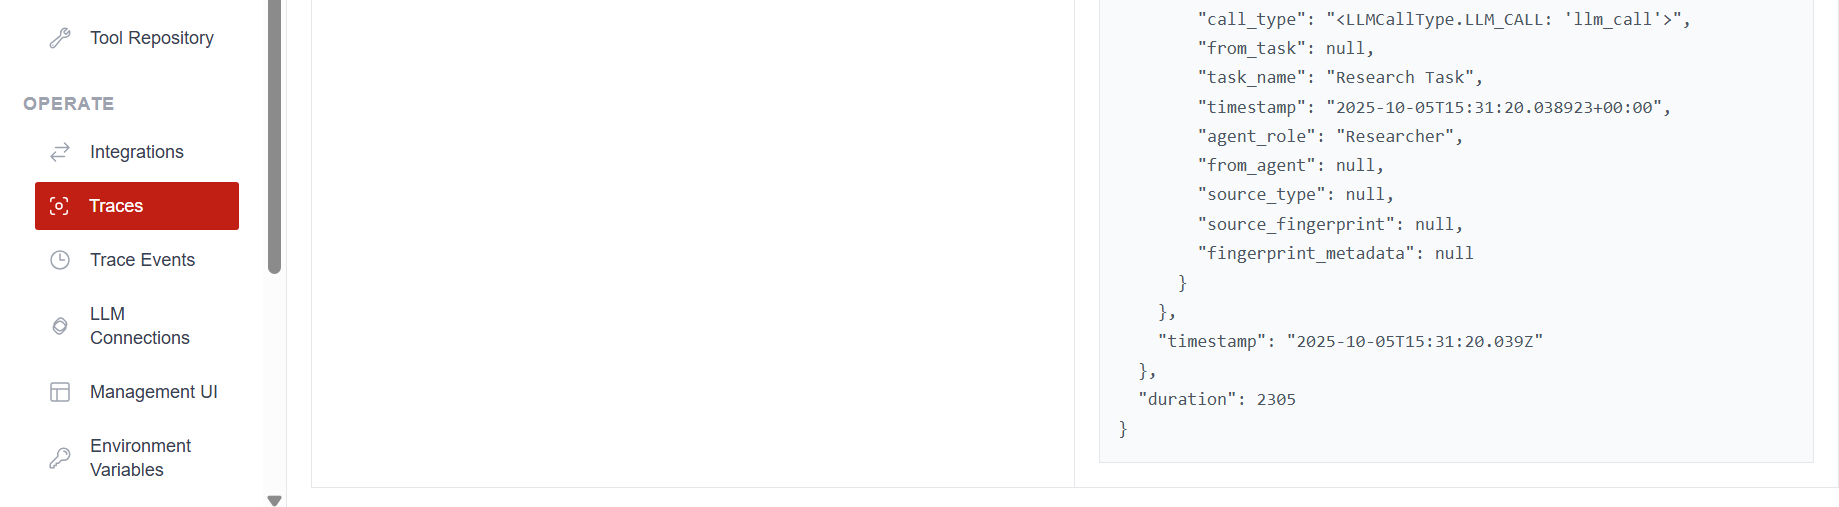

---